# **APS 1 - IA para Automação**
## **Classificador de Falhas em Acionamento de Máquinas Rotativas**
### _Trabalho feito por Bruno Olivares, Gustavo e Lucas Gomes_

#### **1. Panorama do Projeto**

##### Problema a ser resolvido

O projeto tem como objetivo o desenvolvimento de um sistema de aprendizado de máquina, para a classificação da condição operacional de uma máquina rotativa acionada por motor elétrico. A classificação deve ser realizada a partir de atributos obtidos de grandezas elétricas e sinais de vibração, como corrente de entrada e saída, potência, desvio-padrão, amplitude, curtose e magnitudes de frequência dos sensores de vibração.

As possíveis classes de saída são:
- Normal;
- Desacoplado;
- Sobrecarga;
- Desbalanceado;
- Desalinhado.

Os atributos  e condições operacionais analisados podem ser vistos na tabela abaixo:

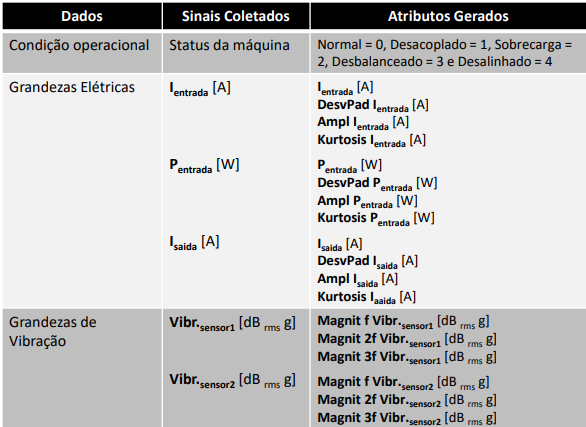

Portanto, trata-se de um problema de classificação supervisionada multiclasse. O modelo recebe os atributos medidos como entrada e deve indicar uma das cinco condições operacionais como saída.



##### Escolha da métrica de desempenho

Antes de desenvolver o modelo de classificação, é importante entender as métricas de avaliação adequadas para o projeto.

Acurácia mede a taxa de acerto total, através da equação:

$$
\text{Acurácia} = \frac{\text{número de classificações corretas}}{\text{total de amostras}}
$$

Ela é útil para ter uma visão geral do modelo. Porém, não deve ser a métrica principal neste projeto. Se houver muito mais registros da condição Normal do que das falhas, o modelo pode alcançar alta acurácia ao prever “Normal” com frequência, mas ainda deixar de identificar falhas importantes. 

Precisão mede, entre os casos previstos como uma classe, quantos realmente pertencem a ela:

$$
\text{Precisão} = \frac{VP}{VP + FP}
$$

onde VP são verdadeiros positivos e FP são falsos positivos. No projeto, alta precisão para “Desbalanceado”, por exemplo, significa que, quando o modelo aponta desbalanceamento, geralmente está correto. É útil para reduzir falsos alarmes e inspeções desnecessárias, mas sozinha não mostra quantas falhas reais foram deixadas de detectar.

Recall mede, entre todos os casos que realmente pertencem a uma classe, quantos foram identificados:

$$
\text{Recall} = \frac{VP}{VP + FN}
$$

onde FN são falsos negativos. Situações de recall alto indica que o sistema está detectando a maior parte das falhas reais. Recall baixo seria perigoso, pois uma máquina com sobrecarga ou desalinhamento poderia ser classificada como normal. Contudo, usado isoladamente, pode levar o modelo a emitir muitos alarmes incorretos.

F1-score combina precisão e recall por meio da média harmônica:

$$
F1 = 2 \times \frac{\text{Precisão} \times \text{Recall}}{\text{Precisão} + \text{Recall}}
$$

O F1-score é uma métrica que combina precisão e recall em um único valor. A precisão mede a confiabilidade de uma previsão: entre as amostras classificadas como uma determinada falha, quantas realmente pertencem àquela classe. O recall mede a capacidade de detecção: entre todas as amostras que realmente apresentam uma falha, quantas foram corretamente identificadas pelo modelo.

O uso do F1-score é adequado porque, em um sistema de diagnóstico de falhas, não é suficiente apenas classificar muitos casos corretamente no total. É necessário evitar tanto falsos alarmes quanto falhas não detectadas. O F1-score penaliza os dois tipos de erro, pois só atinge valor elevado quando precisão e recall também são elevados.

#### **2. Exploração e Pré-Processamento dos Dados**

Como mencionado, para a elaboração do classificador em questão, nos foi fornecido um dataset com diversos dados coletados referente a todas as categorias abordadas pelo problema. Antes de realmente elaborar os algoritmos, é necessário entender com que dados que se está trabalhando e que informações que são possíveis de extrair delas antes de reaizar qualquer progresso, e é essa etapa que será abordada nesse tópico. 

Antes de realizar quaisquer operações, primeiro é necessário importar algumas bibliotecas que serão utilizadas não só nessa etapa, mas durante toda a elaboração do projeto:

In [8]:
# Bibliotecas utilizadas no decorrer do projeto

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict, learning_curve, train_test_split
from sklearn.svm import SVC

Atualmente, o dataset está na forma de csv (Comma Separated Values). De forma que possamos processar as informações de forma adequada via Python, primeiro será transformada o arquivo .csv em um dataframe que pode então ser melhor e visualizado:

In [9]:
# Leitura e Exibição do Dataset

df_maquinas = pd.read_csv("Dataset APS1_Sinais Eletricos e Vibracao_csv.xls")
df_maquinas

,tempo_s,tipo_setup,I_entrada_A,P_entrada_W,I_saida_A,DesvPad_I_entrada_A,DesvPad _P_entrada_W,DesvPad _I_saida_A,Amp_I_entrada_A,Amp_P_entrada_W,Amp_I_saida_A,Kurtosis_I_entrada_A,Kurtosis_P_entrada_W,Kurtosis_I_saida_A,Mag_S1_f1_dBrms,Mag_S1_f2_dBrms,Mag_S1_f3_dBrms,Mag_S2_f1_dBrms,Mag_S2_f2_dBrms,Mag_S2_f3_dBrms
0,0.00,0.0,0.44905,63.67320,1.43660,0.042740,21.869566,0.113479,0.175,91.738,0.406,12.474475,15.435837,4.223108,-50.647991,-63.189443,-47.864704,-59.629807,-73.010381,-49.583755
1,0.08,0.0,0.44610,69.40320,1.67860,0.048945,1.600020,0.854342,0.227,7.359,3.843,20.070610,13.335535,16.966677,-50.696943,-63.340003,-48.313132,-59.591150,-72.360239,-49.473893
2,0.16,0.0,0.45175,69.11385,1.39950,0.042337,5.220348,0.284000,0.207,24.185,1.395,19.087723,7.345771,11.032327,-47.724322,-62.837371,-48.384219,-55.194912,-63.127903,-48.083630
3,0.24,0.0,0.43510,68.85665,1.39705,0.063224,3.437546,0.219507,0.228,16.040,0.973,6.869051,19.849528,9.136137,-47.652608,-62.613368,-48.768793,-55.275822,-63.310116,-47.937933
4,0.32,0.0,0.45055,70.52860,1.43375,0.048497,1.240032,0.111967,0.222,4.394,0.425,20.205840,2.325535,2.818658,-47.019446,-61.314274,-49.016646,-54.665312,-60.825200,-47.886619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2500,39.68,4.0,0.46575,68.42795,1.59235,0.042147,8.058820,0.900427,0.199,37.403,4.276,5.486469,22.266532,21.582764,-33.195195,-52.502279,-41.610532,-37.874381,-49.147213,-42.417970
2501,39.76,4.0,0.44705,62.32815,1.57365,0.068987,15.876663,0.904702,0.231,62.159,4.218,5.237910,11.518238,21.593782,-33.360763,-52.868492,-42.054637,-37.995903,-49.251871,-42.703237
2502,39.84,4.0,0.47110,76.04075,1.77275,0.045194,34.799709,1.657858,0.191,184.906,7.810,9.874863,20.660427,6.075266,-33.497896,-53.300911,-42.289221,-38.129107,-48.947030,-42.896321
2503,39.92,4.0,0.47745,72.86850,1.39700,0.043033,0.826486,0.131019,0.194,2.893,0.383,21.320253,2.327027,1.904577,-33.581380,-53.601503,-42.527074,-38.258422,-48.618126,-42.420583


Nessa configuração, nossa variável alvo é o "tipo_setup", o qual descreve se a condição operacional da máquina está normal (0), desacoplado (1), sobrecarregado (2), desbalanceado (3) ou desalinhado (4). De resto, temos informações referentes à corrente de entrada, corrente de saída do motor e potência de entrada (média, desvio padrão, amplitude e kurtosis) além da informação da frequência natural, segunda harmônica e terceira harmônica. 

Em um primeiro momento, podemos levantar algumas informações na forma de estatísticas descritivas se utilizando do comando .describe() do pandas, cujo resultado pode ser visto abaixo:

In [10]:
# Estatísticas Descritivas Geral dos atributos do dataset de interesse

print("Estatísticas Descritivas Gerais")
df_maquinas_cut_param = df_maquinas.iloc[:, 2:]
df_maquinas_cut_param.describe()

Estatísticas Descritivas Gerais


,I_entrada_A,P_entrada_W,I_saida_A,DesvPad_I_entrada_A,DesvPad _P_entrada_W,DesvPad _I_saida_A,Amp_I_entrada_A,Amp_P_entrada_W,Amp_I_saida_A,Kurtosis_I_entrada_A,Kurtosis_P_entrada_W,Kurtosis_I_saida_A,Mag_S1_f1_dBrms,Mag_S1_f2_dBrms,Mag_S1_f3_dBrms,Mag_S2_f1_dBrms,Mag_S2_f2_dBrms,Mag_S2_f3_dBrms
count,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000,2505.000000
mean,0.467173,71.095485,1.510273,0.062549,10.030840,0.495564,0.280475,46.371912,2.225988,12.050777,14.937885,11.168255,-39.983011,-54.772230,-47.535366,-45.145129,-55.583079,-46.578764
std,0.037798,6.369966,0.138248,0.057536,11.105669,0.375317,0.269268,52.036291,1.767510,5.230828,6.931692,7.207961,4.949400,9.313107,5.857693,6.269441,9.072283,3.855181
min,0.261900,38.470250,0.810650,0.001372,0.543396,0.063909,0.005000,1.893000,0.244000,1.660392,1.325033,1.187931,-50.696943,-71.520216,-58.985078,-65.271484,-73.010381,-54.985263
25%,0.445700,67.307950,1.419950,0.041017,2.689081,0.154070,0.183000,12.789000,0.596000,7.971048,9.554414,4.030760,-43.902336,-59.541521,-52.053099,-50.245276,-63.067057,-49.493122
50%,0.456750,69.612150,1.479250,0.056569,8.407893,0.377251,0.244000,38.618000,1.745000,10.701860,16.355427,9.754281,-41.943547,-54.967319,-47.868026,-48.353184,-59.158229,-47.233461
75%,0.472450,73.029150,1.590750,0.070714,12.983316,0.879553,0.302000,58.301000,4.108000,15.927991,21.599938,18.540216,-34.647596,-50.619857,-41.947513,-37.978948,-49.267334,-42.830915
max,0.625950,96.651550,2.118200,0.860274,149.491667,2.007972,3.881000,672.213000,10.687000,22.979158,22.994930,22.794465,-31.993773,-37.605394,-36.684861,-35.173001,-37.765710,-38.495491


Por mais que tenhamos essas informações, é necessário verificar se houve quaisquer falhas de input na hora do teste, gerando entradas do tipo NaN. Para verificar se houve ocorrências, é possível realizar a seguinte linha de código:

In [11]:
df_maquinas.isna().sum()

tempo_s                 0
tipo_setup              0
I_entrada_A             0
P_entrada_W             0
I_saida_A               0
DesvPad_I_entrada_A     0
DesvPad _P_entrada_W    0
DesvPad _I_saida_A      0
Amp_I_entrada_A         0
Amp_P_entrada_W         0
Amp_I_saida_A           0
Kurtosis_I_entrada_A    0
Kurtosis_P_entrada_W    0
Kurtosis_I_saida_A      0
Mag_S1_f1_dBrms         0
Mag_S1_f2_dBrms         0
Mag_S1_f3_dBrms         0
Mag_S2_f1_dBrms         0
Mag_S2_f2_dBrms         0
Mag_S2_f3_dBrms         0
dtype: int64

Com esse comando, é possível ver que não existem inputs do tipo NaN dentro do dataset. Entretanto, pode ser que certos valores não sigam o padrão de float que se espera (preenchidos com um caracter especial, por exemplo). Para ver isso, é possível executar a seguinte linha de código:

In [12]:
colunas = df_maquinas.columns.tolist()

for param in colunas:

    vals_coluna =  df_maquinas[param].tolist()

    total_col = 0

    for val in vals_coluna:

        if not float(val):

            if val != 0:

                total_col += 1

    print(f"{param} teve {total_col} entradas inválidas identificadas")


tempo_s teve 0 entradas inválidas identificadas
tipo_setup teve 0 entradas inválidas identificadas
I_entrada_A teve 0 entradas inválidas identificadas
P_entrada_W teve 0 entradas inválidas identificadas
I_saida_A teve 0 entradas inválidas identificadas
DesvPad_I_entrada_A teve 0 entradas inválidas identificadas
DesvPad _P_entrada_W teve 0 entradas inválidas identificadas
DesvPad _I_saida_A teve 0 entradas inválidas identificadas
Amp_I_entrada_A teve 0 entradas inválidas identificadas
Amp_P_entrada_W teve 0 entradas inválidas identificadas
Amp_I_saida_A teve 0 entradas inválidas identificadas
Kurtosis_I_entrada_A teve 0 entradas inválidas identificadas
Kurtosis_P_entrada_W teve 0 entradas inválidas identificadas
Kurtosis_I_saida_A teve 0 entradas inválidas identificadas
Mag_S1_f1_dBrms teve 0 entradas inválidas identificadas
Mag_S1_f2_dBrms teve 0 entradas inválidas identificadas
Mag_S1_f3_dBrms teve 0 entradas inválidas identificadas
Mag_S2_f1_dBrms teve 0 entradas inválidas identifica

Fazendo essa verificação, é possível concluir que todo o dataset está devidamente preenchido com dados, o que significa que nenhuma manipulação par tratar de dados faltantes deve ser feita.

De forma complementar, não é possível descartar a hipótese de que os dados coletados e presentes em cada um dos atributos são de fato consistentes, uma vez que pode estar envolvido o erro humano de realizar inputs equivocados, por exemplo. Porém, analisando as estatísticas:

1. Os valores de corrente de entrada, corrente de saída e potência de entrada parecem coerentes, podendo-se apoiar também na ideia que a corrente de entrada é referente à utilizada pelo inversor, o que é significadamente menor que a corrente usada pelo motor, e de que potência é diretamente proporcional à corrente e, considerando corrente de entradas na escala de miliampere e tensão de rede de 220V, os valores de potência são razoáveis também;
2. Os parâmetros de desvio, amplitude e kurtosis não são medidos por sensores, mas são resultados de manipulações matemáticas dos valores de corrente de entrada, corrente de saída e potência de entrada. Logo, se esses foram colocados corretamente, a chance dos parâmetros em questão serem incosistentes é muito baixa;
3. Por fim.... **(verificar a questão da frequência natural e harmônicas de novo com o Ferraz)**

Como parte dessa etapa, também é ideal verificar se todas as casses estão balanceadas, isso é, que todas as classes tenham a mesma quantidade de ocorrências. Para verificar isso, pode-se implementar o seguinte código: 

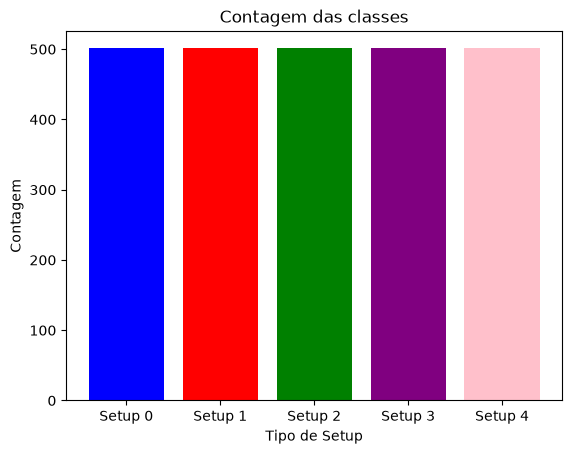

In [13]:
# Contagem das ocorrências de classes

contagem = df_maquinas["tipo_setup"].value_counts()

plt.bar(["Setup 0", "Setup 1", "Setup 2", "Setup 3", "Setup 4"], [contagem[0], contagem[1], contagem[2], contagem[3], contagem[4]], color = ["blue", "red", "green", "purple", "pink"])
plt.title("Contagem das classes")
plt.xlabel("Tipo de Setup")
plt.ylabel("Contagem")
plt.show()

Neste caso, é possível ver que o dataset já possui a quantidade de ocorrências de cada classe balanceada desde o começo, não sendo necessário realizar quaisquer operações nessa frente.

Por mais que hajam sido extraídas as informações estatísticas, é possível visualizá-las de formas alternativas se utilizando de gráficos complementares. Por exemplo, é possível elaborar um gráfico de barras que descreve a distribuição dos parâmetros utilizados:

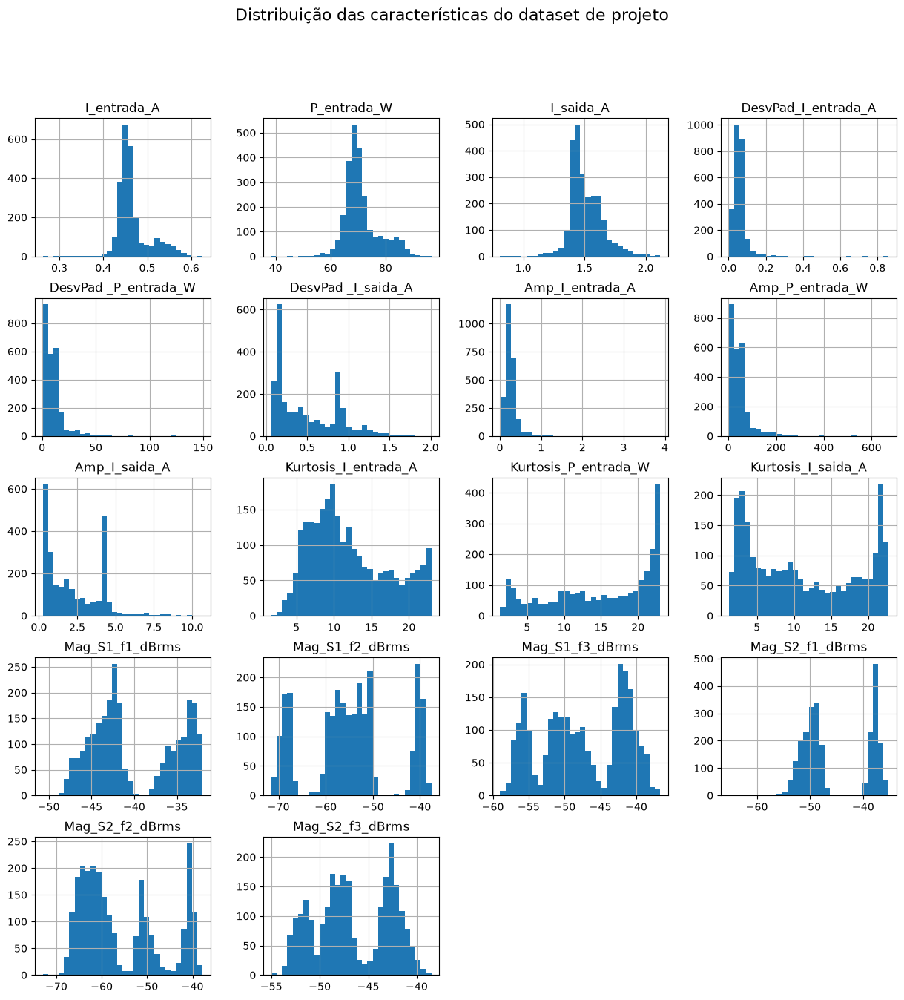

In [14]:
# Gráfico de Barra para visualizar a distribuição de atributos

df_maquinas_cut_param.hist(figsize=(15, 15), bins = 30)
plt.suptitle('Distribuição das características do dataset de projeto', fontsize=16)
plt.show()

Com esses gráficos, enquanto se observa que os valores médios de corrente de entrada, potência de entrada e corrente de saída possuem comportamentos normais, o que indica que não existe muita variação dessas informações entre as diferentes classes. Porém, gráficos com mais de um pico a exemplo dos gráficos de Kurtosis de corrente de saída e segunda harmônica do primeiro sensor de vibração também podem ser observados, esses que geram maior interesse uma vez que a existência de mais de um pico indicam que existem mais de um comportamento entre as classes que podem ser exclusivo delas, o que pode ser utilizado a nosso favor na hora de selecionar um determinado atributo para elaborar um algoritmo de classificação.

É possível também visualizar o comportamento desses comportamentos de cada parâmetro lado a lado se utilizando de um boxplot, assim como é visto na célula a seguir:

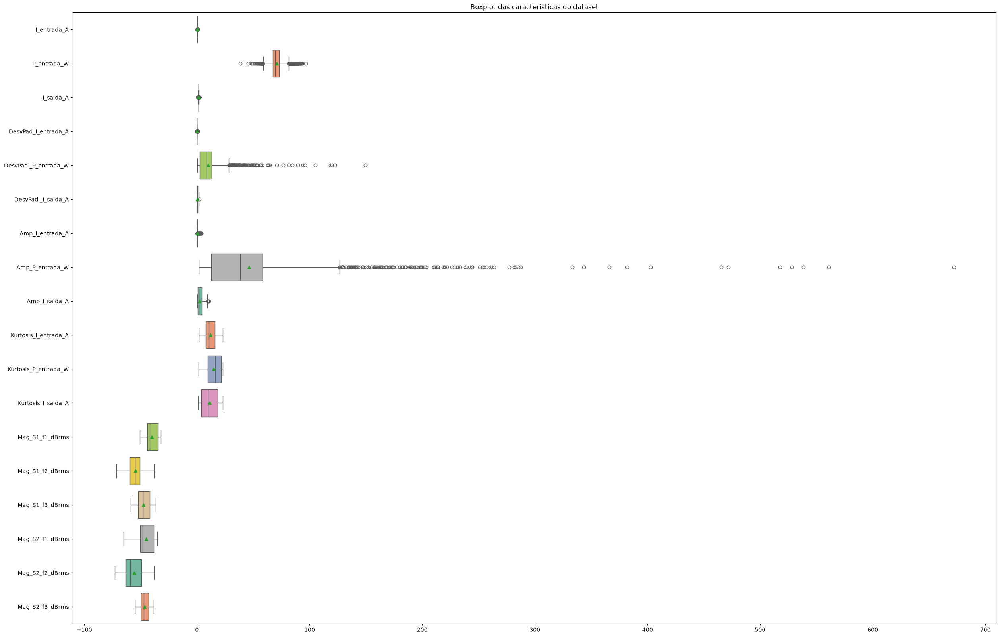

In [15]:
# Conjunto de boxplots de cada um dos parâmetros

plt.figure(figsize=(30, 20))
sns.boxplot(data=df_maquinas_cut_param, showmeans=True, orient='h', palette='Set2')
plt.title('Boxplot das características do dataset')
plt.show()

Entretanto, uma coisa a se considerar é que estamos tratando de dados de grandezas e escalas totalmente diferentes, por conta disso, as informações que podem ser extrídas por esse gráfico são quase nulas, e as futuras interpretações desses resultados, especialmente quando colocados em análise de pares, pode vir a atrapalhar e gerar conclusões precipitadas. Para resolver essa questão, podemos realizar uma normalização dos dados de forma a convertê-los para a mesma grandeza e escala, assim como é feito na célula seguinte:

In [16]:
# Normalização dos resutados

scaler = StandardScaler()
scaler.set_output(transform="pandas")
df_param_norm = scaler.fit_transform(df_maquinas_cut_param)

df_param_norm

,I_entrada_A,P_entrada_W,I_saida_A,DesvPad_I_entrada_A,DesvPad _P_entrada_W,DesvPad _I_saida_A,Amp_I_entrada_A,Amp_P_entrada_W,Amp_I_saida_A,Kurtosis_I_entrada_A,Kurtosis_P_entrada_W,Kurtosis_I_saida_A,Mag_S1_f1_dBrms,Mag_S1_f2_dBrms,Mag_S1_f3_dBrms,Mag_S2_f1_dBrms,Mag_S2_f2_dBrms,Mag_S2_f3_dBrms
0,-0.479564,-1.165433,-0.533011,-0.344360,1.066220,-1.018235,-0.391789,0.871990,-1.029896,0.081016,0.071851,-0.963731,-2.155233,-0.903983,-0.056234,-2.310823,-1.921323,-0.779624
1,-0.557625,-0.265719,1.217822,-0.236494,-0.759297,0.956124,-0.198635,-0.749875,0.915036,1.533492,-0.231209,0.804608,-2.165125,-0.920153,-0.132803,-2.304656,-1.849646,-0.751121
2,-0.408118,-0.311152,-0.801424,-0.351366,-0.433243,-0.563806,-0.272925,-0.426459,-0.470240,1.345552,-1.095494,-0.018862,-1.564403,-0.866172,-0.144942,-1.603299,-0.831801,-0.390427
3,-0.848701,-0.351537,-0.819149,0.011729,-0.593806,-0.735677,-0.194920,-0.583016,-0.709041,-0.990811,0.708719,-0.281983,-1.549911,-0.842115,-0.210607,-1.616207,-0.851889,-0.352627
4,-0.439872,-0.089011,-0.553630,-0.244282,-0.791718,-1.022265,-0.217207,-0.806866,-1.019144,1.559350,-1.819883,-1.158617,-1.421958,-0.702596,-0.252928,-1.518809,-0.577933,-0.339314
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2500,-0.037658,-0.418851,0.593816,-0.354669,-0.177604,1.078938,-0.302641,-0.172393,1.160062,-1.255178,1.057478,1.445151,1.371716,0.243786,1.011664,1.159944,0.709540,1.079489
2501,-0.532487,-1.376630,0.458525,0.111912,0.526487,1.090330,-0.183777,0.303447,1.127241,-1.302705,-0.493434,1.446679,1.338257,0.204456,0.935833,1.140557,0.698002,1.005478
2502,0.103910,0.776496,1.898983,-0.301700,2.230736,3.097450,-0.332357,2.662791,3.159885,-0.416062,0.825727,-0.706719,1.310545,0.158015,0.895778,1.119306,0.731610,0.955384
2503,0.271941,0.278395,-0.819511,-0.339267,-0.828963,-0.971492,-0.321214,-0.835717,-1.042911,1.772440,-1.819668,-1.285458,1.293674,0.125733,0.855165,1.098676,0.767871,1.078811


Feita a normalização e refazendo o boxplot anterior, é possível obter o seguinte resultado:

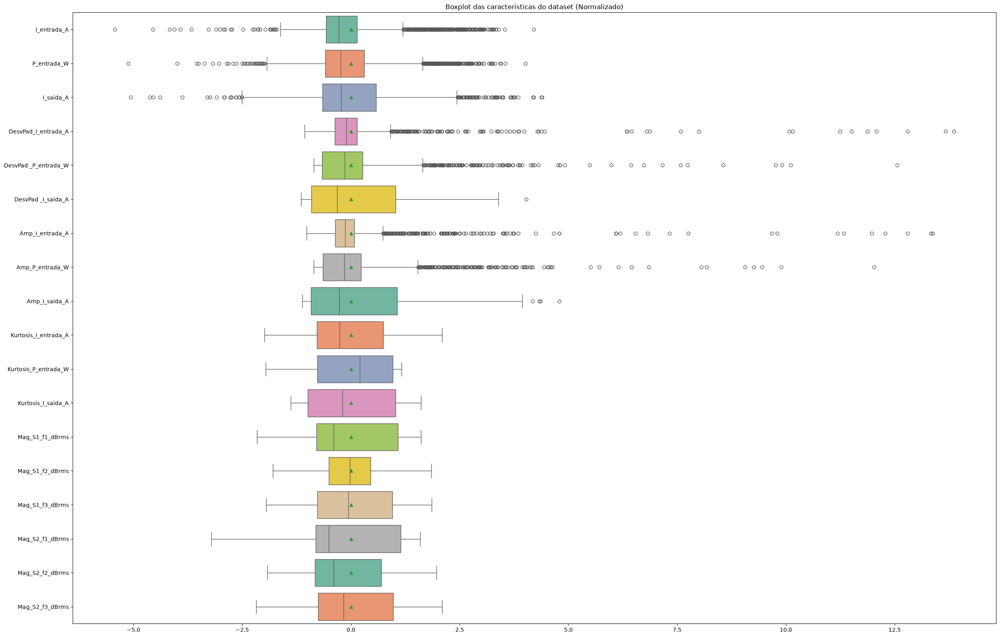

In [17]:
# Conjunto de boxplots de cada um dos parâmetros

plt.figure(figsize=(30, 20))
sns.boxplot(data=df_param_norm, showmeans=True, orient='h', palette='Set2')
plt.title('Boxplot das características do dataset (Normalizado)')
plt.show()

Como se pode ver, agora todas os parâmetros estão em mesma escala e não estão mais totalmente distorcidos como na tentativa anterior. Fica também evidente a existência de muitos outliers em diversos parâmetros, o que pode se dar visto que todas as classes estão misturadas nesse gráfico e certos tipos de comportamentos diferentes são esperados, gerando esses outliers. Entretanto, deve-se atentar também ao fato de que os parâmetros de kurtosis e os parâmetros de rúido não apresentaram quaiquer outliers, podendo ser traduzido em uma confiabilidade maior desses parâmetros.

Como a elaboração de um algoritmo de classificação baseia-se nas leituras das relações entre os atributos e a variável alvo de forma a encontrar diferencias que ajudem a separar as classes desejadas, podemos iniciar a visualizar essas relações através de uma matriz de confusão, a qual exibe o grau de correlação entre as variáveis. Esse mesmo gráfico pode ser visto a seguir:

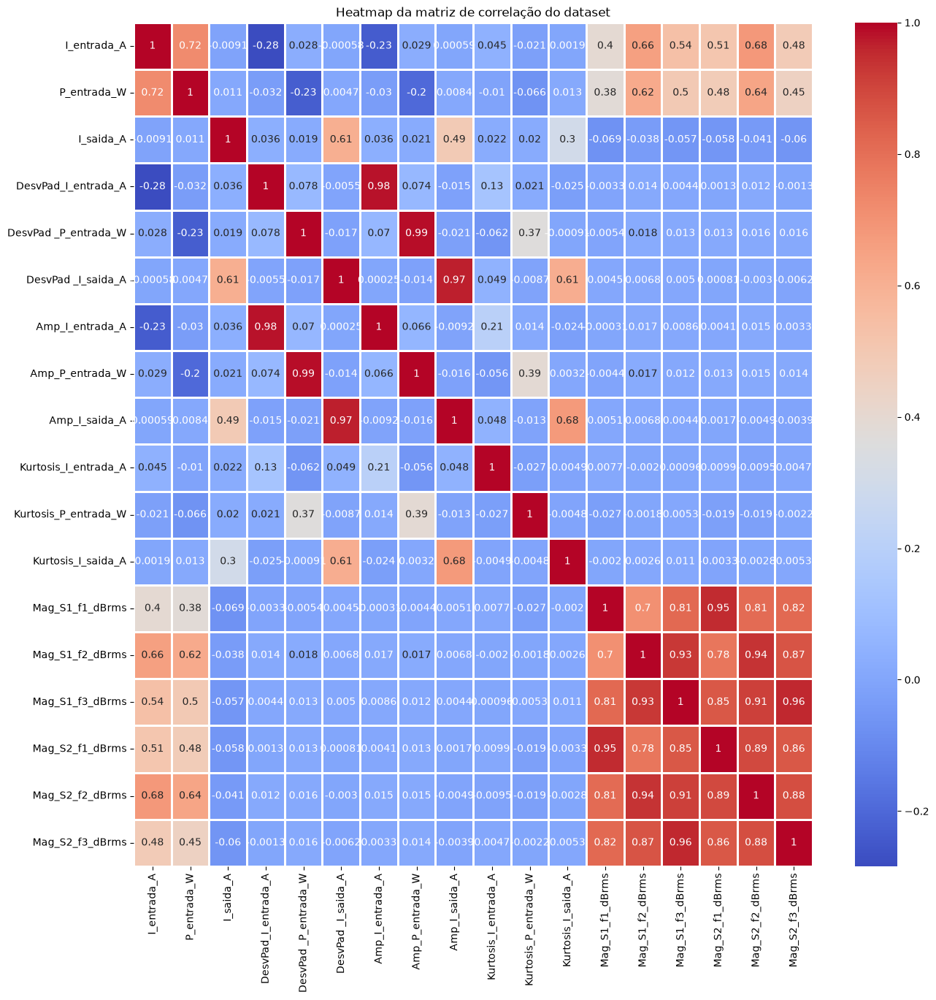

In [18]:
# Elaboração da Matriz de Confusão

correlation_matrix = df_maquinas_cut_param.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=1)
plt.title('Heatmap da matriz de correlação do dataset')
plt.show()

Maiores graus de correlação normalmente indicam que os parâmetros em questão oferecem o mesmo tipo de informação, podendo significar redundância de atributos, o que pode ser utilizado para reaalizar a redução de dimensionalidade do problema numa etapa futura. Nesse gráfico, podemos ver:
- Alto grau de correlação entre os parâmetros de vibração de ambos os sensores;
- Médio grau de correlação entre esses mesmos parâmetros com a corrente e potência de entrada;
- Alto grau de correlação entre o desvio padrão de corrente de entrada e amplitude de corrente de entrada;
- Alto de correlação entre o desvio padrão de potência de entrada e amplitude de potência de entrada;
- Alto grau de correlação entre o desvio padrão de corrente de saída e amplitude de corrente de saída;
- Médio grau de correlação entre a kurtosis de corrente de saída com o desvio padrão e amplitude de corrente de saída;
- Médio de correlação entre corrente de entrada e potência de entrada;
- Médio de correlação entre corrente de saída com desvio padrão e amplitude de corrente de saída;

Além desse gráfico, é possível utilizar de um gráfico de pares de forma a visualizar como os resultados de cada classe estão espalhados em cada comparação de parâmetro de forma a tentar pré-visualizar separações de cada classe. Essa lógica pode ser vista no gráfico abaixo:

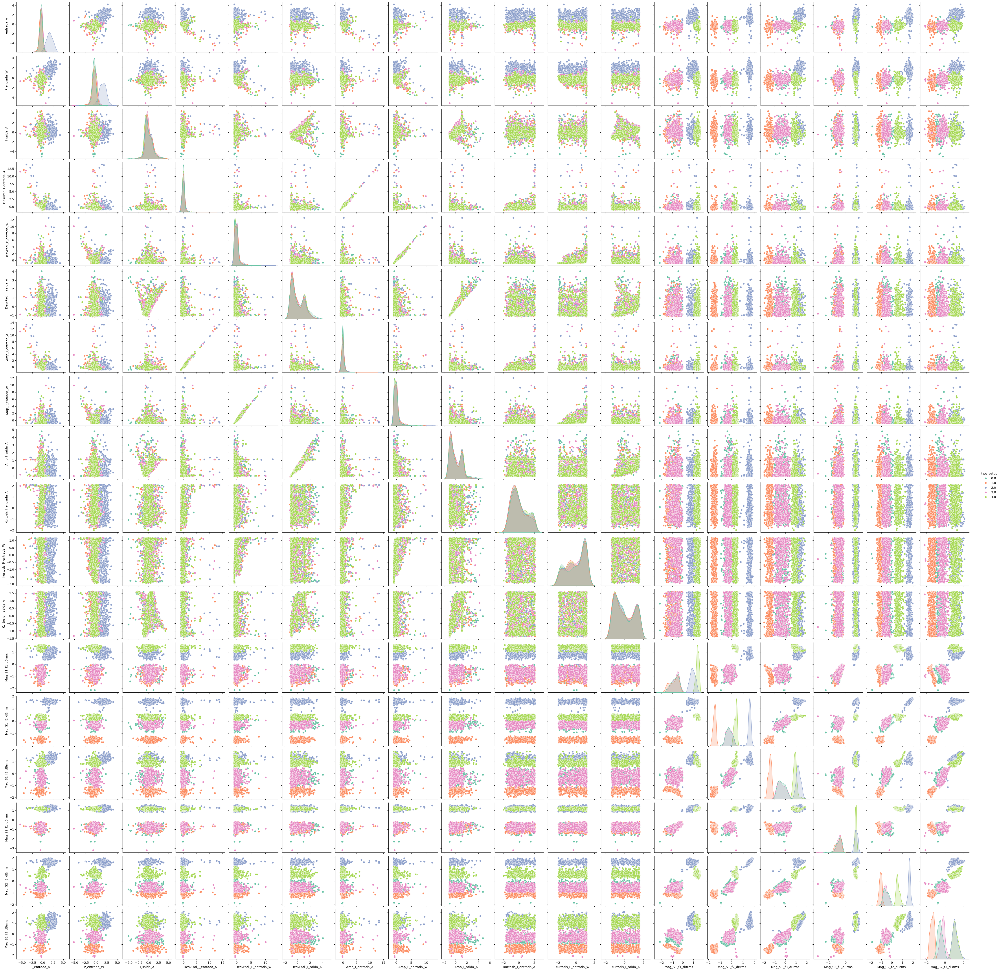

In [19]:
# Elaboração do Gráfico de Pares

new_df_maquinas = pd.concat([df_maquinas["tipo_setup"], df_param_norm], axis=1)

sns.pairplot(new_df_maquinas, hue='tipo_setup', palette='Set2')
plt.show()

Nesse caso, é possível observar que o uso dos dados de vibração tanto quando combinados entre eles quanto com outros parâmetros, é possível realizar uma certa delimitação entre as classes. Essa propriedade traz mais valor para esses atributos, especialmente quando se pensa que pode ser viável a redução da dimensionalidade do problema para facilitá-lo e evitar overfitting. Além disso, uma separação leve de classes pode ser vista na combinação das kurtosis com a corrente de entrada e potência de entrada, sendo um outro parâmetro com um certo grau de valor para a construção dos futuros modelos.

Além dos gráficos previamente exibidos, podemos também realizar boxplots de cada um dos atributos para cada uma das classes de forma a visualizar de um outro ângulo como que cada atributo "divide" as classes de interesse além de visualizar a distribuição dos atributos por cada classe desses atributos. Essa etapa pode ser vista na seguinte célula:

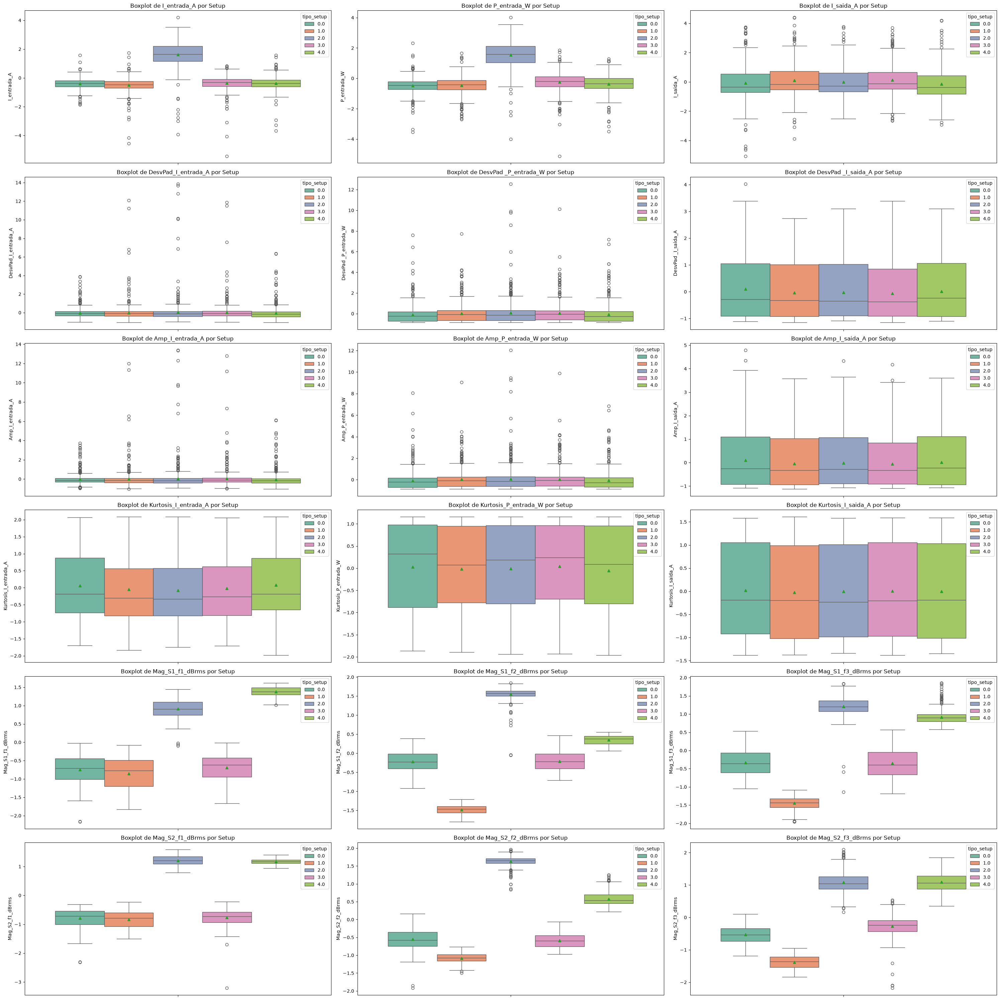

In [20]:
plt.figure(figsize=(30, 30))

for i, column in enumerate(new_df_maquinas.drop(columns=["tipo_setup"]).columns):

    plt.subplot(6, 3, i+1)
    sns.boxplot(hue="tipo_setup", y=column, data=new_df_maquinas, showmeans=True, palette='Set2')
    plt.title(f'Boxplot de {column} por Setup')
    
plt.tight_layout()
plt.show()

Com esses gráficos, é possível não apenas ter uma nova visão do boxplot feito anteriormente com todos os parâmetros comparados e normalizados, mas é possível analizar os comportamentos desses parâmetros dentro de cada classe. Com esse tipo de gráfico, busca-se analizar os boxplots que não se sobrepoem entre classes, visto que, quando isso acontece, significa que o parâmetro em questão é particular de um/algumas classes apenas, logo ele pode ser utilizado como um fator de classificação dos modelos a serem construídos. Nessa mesma linha, boxplots que se sobrepoem não agregam informação alguma, assim como visto, por exemplo, nos parâmetros de kurtosis. Em contraste com o gráfico anterior, as kurtosis não tem muito valor sozinhas, mas quando combinadas, por exemplo, com os parâmetros de ruído, é possível ver melhores resultados. Além disso, mais uma vez, os parâmetros de ruído novamente, especialmente a S1_f1 e S2_f1 apresentam potencial de uso por separarem os setups 2 e 4 dos demais. Os outros parâmetros de ruído também conseguem fazer o mesmo de forma muito semelhante, mas a presença de outliers mostra um sinal de alerta. Os valores de corrente de entrada e potência de entrada também possuem potencial para o setup 2, porém, como também apresentam outliers, deve-se ter cautela com tal atributo.

Como previamente mencionado, o dataset em questão possui 18 atributos diferentes a serem analisados para a criação do classificador. Por mais que mais parâmetros possam nos fornecer mais tipos de informação para a classificação, alguns, assim como discutido anteriormente, passam mais ou menos informações para o modelo. Por conta disso, utilizar de todos os parâmetros disponíveis podem fazer o modelo ficar extremamente treinado para detectar muitos detalhes muitas vezes desnecessários, o que pode ocasionar overfitting do modelo. Por conta disso, pode-se pensar em reduzir a dimensão do problema pela eliminação de parâmetros e/ou pela junção de parâmetros.

Como uma primeira iteração para que seja possível construir a primeira versão dos modelos, e tendo discutido as individualidades de maioria dos parãmetros na seção anterior, vamos selecionar os 8 parâmetros mais relevantes a partir do uso do comando SelectKBest, o qual atribui notas aos parâmetros relacionados à capacidade de predição do modelo, sendo as maiores notas os parâmetros mais promissores:

In [21]:
# Selecionar os 8 melhores atributos com base em mutual_info_classif

selector = SelectKBest(score_func = mutual_info_classif, k = 8)
df_param_reduc_filter = selector.fit_transform(df_param_norm, df_maquinas["tipo_setup"])

df_param_reduc_filter

array([[-0.47956404, -1.16543274, -2.15523298, ..., -2.31082333,
        -1.92132259, -0.77962379],
       [-0.55762526, -0.26571924, -2.16512544, ..., -2.30465616,
        -1.84964584, -0.75112087],
       [-0.40811818, -0.31115242, -1.56440322, ..., -1.60329924,
        -0.83180065, -0.39042687],
       ...,
       [ 0.1039105 ,  0.77649599,  1.31054461, ...,  1.11930594,
         0.7316101 ,  0.9553841 ],
       [ 0.27194058,  0.27839545,  1.29367375, ...,  1.09867558,
         0.76787106,  1.07881099],
       [ 0.52597031, -0.06097554,  1.2899964 , ...,  1.08636564,
         0.79807478,  1.19575829]], shape=(2505, 8))

Esse código apenas nos retorna as listas de cada parâmetro relacionados. Na célula abaixo, é possível observar quais notas foram atribuídas aos parâmetros e então definir quais parâmetros foram selecionados ao final:

In [22]:
# Exibir as pontuações dos atributos
scores = selector.scores_
columns = df_param_norm.columns
feature_scores = pd.DataFrame({'Atributo': columns, 'Pontuação': scores}).sort_values(by='Pontuação', ascending=False)

print("Pontuações dos Atributos:")
print(feature_scores)

Pontuações dos Atributos:
                Atributo  Pontuação
16       Mag_S2_f2_dBrms   1.238016
13       Mag_S1_f2_dBrms   1.219430
14       Mag_S1_f3_dBrms   1.140709
17       Mag_S2_f3_dBrms   1.075853
12       Mag_S1_f1_dBrms   0.866717
15       Mag_S2_f1_dBrms   0.751251
0            I_entrada_A   0.443329
1            P_entrada_W   0.407216
3    DesvPad_I_entrada_A   0.038038
2              I_saida_A   0.034105
4   DesvPad _P_entrada_W   0.022060
8          Amp_I_saida_A   0.012691
5     DesvPad _I_saida_A   0.009022
7        Amp_P_entrada_W   0.003311
9   Kurtosis_I_entrada_A   0.001926
6        Amp_I_entrada_A   0.000000
10  Kurtosis_P_entrada_W   0.000000
11    Kurtosis_I_saida_A   0.000000


Pode-se observar que as 8 maiores notas foram atribuídas a todos os parâmetros dos sensores de vibração junto à corrente e potência de entrada. Analisando essa decisão, a seleção dos parâmetros de vibração fazem muito sentido visto todas as informações vistas nos gráficos de pares, matriz de confusão e boxplots. Porém, também ficou evidente que esses parâmetros combinados com outros atributos podem agregar ainda mais dados, logo a escolha de corrente e potência de entrada como suporte também fazem sentido a partir das análises anteriores. Existe a possibilidade de talvez selecionar apenas um dos sensores de vibração visto que ambos possuem alto indice de correlação, além de juntar todos os atributos de um sensor em um único parâmetro, mas essa iteração pode ser implementada mais adiante. No momento, vamos trabalhar apenas com os 8 parâmetros de melhor nota.

##### **3. Implementação dos Classificadores**

Tendo o dataset em mãos agora com parâmetros filtrados, podemos iniciar o processo de criação dos algoritmos de classificação. Como visto em aula, iremos fazer a implementação de 3:

- KNN Classifier
- Decision Tree
- SVM

Cada um possui suas individualidades e parâmetros, sendo necessário explorar os diferentes resultados quando os modelos são variados se utilizando das ferramentas vistas no curso até o momento como a curva de aprendizado, curva ROC e o Classification Report. Além disso, também será utilizada o método de amostragem cross-validation, o qual permite que se considere a variância dos resultados (nesse caso, o desejado F1-score) quando se varia como são arranjados os dados.

Considerando que estamos tratando de um problema com dimensão reduzidos, iremos trabalhar com os dois seguintes dataframes:

In [23]:
X_df = df_param_norm.drop(columns=["DesvPad_I_entrada_A", 
                           "I_saida_A", 
                           "DesvPad _P_entrada_W", 
                           "Amp_I_saida_A", 
                           "DesvPad _I_saida_A", 
                           "Amp_P_entrada_W", 
                           "Kurtosis_I_entrada_A", 
                           "Amp_I_entrada_A", 
                           "Kurtosis_P_entrada_W",
                            "Kurtosis_I_saida_A"])

Y_df = df_maquinas["tipo_setup"]

X_treino, X_teste, y_treino, y_teste = train_test_split(X_df, Y_df, test_size = 0.3, random_state=1, shuffle=True)

##### **3.1. KNN Classifier**

In [24]:
#Importação de bibliotecas

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from matplotlib import pyplot as plt

O KNN Classifier (K-Nearest Neighbors) é um método de classificação baseado em instâncias. Para classificar uma nova amostra, o algoritmo calcula a distância dela até todas as amostras armazenadas, identifica as k mais próximas e atribui a classe mais frequente entre esses k vizinhos. Diferente da Decision Tree e do SVM, ele não possui uma fase de treinamento propriamente dita: apenas armazena o conjunto de dados, e o custo computacional é transferido para o momento da predição.

Como a classificação depende inteiramente de distâncias, atributos com escalas maiores dominariam o cálculo e distorceriam a vizinhança, o que torna a normalização essencial, etapa já realizada na seção 2. Além disso, o KNN é sensível ao número de dimensões: quanto mais atributos, menos as distâncias conseguem distinguir amostras próximas de distantes, e atributos pouco informativos adicionam ruído ao cálculo. Por isso a redução de atributos, iniciada na seção 2 e aprofundada na seção 4, é especialmente relevante para esse modelo.

Os hiperparâmetros analisados serão o número de vizinhos (k), que controla o equilíbrio entre sensibilidade a ruído (k pequeno) e suavização excessiva da fronteira de decisão (k grande), e a medida de distância utilizada. Os modelos serão avaliados com validação cruzada, classification_report, matriz de confusão, curvas ROC e curvas de aprendizado.

In [36]:
# Iniciando KNN Classifier

#Criando listas vazias para armazenar os resultados
k_list = []
f1_setupknn0 = []
f1_setupknn1 = []
f1_setupknn2 = []
f1_setupknn3 = []
f1_setupknn4 = []
acc_lista = []
f1_macroknn = []
f1_weightedknn = []

#Definindo os valores de k
k_values = list(range(1,50))

#Iterando os valores de K

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    y_pred_knn = cross_val_predict(knn, X_df, Y_df, cv=20)
    
    dic_relatorio = classification_report(Y_df, y_pred_knn, output_dict=True)
    
    k_list.append(k)
    f1_setupknn0.append(dic_relatorio["0.0"]["f1-score"] * 100)
    f1_setupknn1.append(dic_relatorio["1.0"]["f1-score"] * 100)
    f1_setupknn2.append(dic_relatorio["2.0"]["f1-score"] * 100)
    f1_setupknn3.append(dic_relatorio["3.0"]["f1-score"] * 100)
    f1_setupknn4.append(dic_relatorio["4.0"]["f1-score"] * 100)
    
    acc_lista.append(dic_relatorio["accuracy"] * 100)
    f1_macroknn.append(dic_relatorio["macro avg"]["f1-score"] * 100)
    f1_weightedknn.append(dic_relatorio["weighted avg"]["f1-score"] * 100)
    

# Montagem do dicionário estrutural nomeando as colunas
df_dict = {
    "k": k_list,
    "F1 Score Setup 0": f1_setupknn0,
    "F1 Score Setup 1": f1_setupknn1,
    "F1 Score Setup 2": f1_setupknn2,
    "F1 Score Setup 3": f1_setupknn3,
    "F1 Score Setup 4": f1_setupknn4,
    "Acurácia": acc_lista,
    "F1 Macro": f1_macroknn,
    "F1 Ponderado": f1_weightedknn
}

#Criando o DataFrame a partir do dicionário
df_resultados_knn = pd.DataFrame(df_dict)

#Exibindo o DataFrame com os resultados
df_resultados_knn



,k,F1 Score Setup 0,F1 Score Setup 1,F1 Score Setup 2,F1 Score Setup 3,F1 Score Setup 4,Acurácia,F1 Macro,F1 Ponderado
0,1,70.624360,100.000000,99.800000,72.108844,100.000000,88.502994,88.506641,88.506641
1,2,74.028269,99.900299,99.800000,66.208477,100.000000,88.183633,87.987409,87.987409
2,3,71.033777,100.000000,99.800000,72.497570,100.000000,88.662675,88.666269,88.666269
3,4,74.317968,99.900299,99.800000,70.912951,100.000000,89.021956,88.986244,88.986244
4,5,70.146138,99.900299,99.699700,72.588348,99.900299,88.463074,88.446957,88.446957
5,6,73.339750,99.900299,99.700300,71.221532,99.900100,88.822355,88.812396,88.812396
6,7,71.816284,99.900299,99.699700,74.116523,99.900299,89.101796,89.086621,89.086621
7,8,74.513619,99.900299,99.699700,73.080860,99.900299,89.421158,89.418955,89.418955
8,9,71.428571,99.900299,99.699700,73.339750,99.900299,88.862275,88.853724,88.853724
9,10,74.196689,99.900299,99.699700,72.801636,99.900299,89.301397,89.299725,89.299725


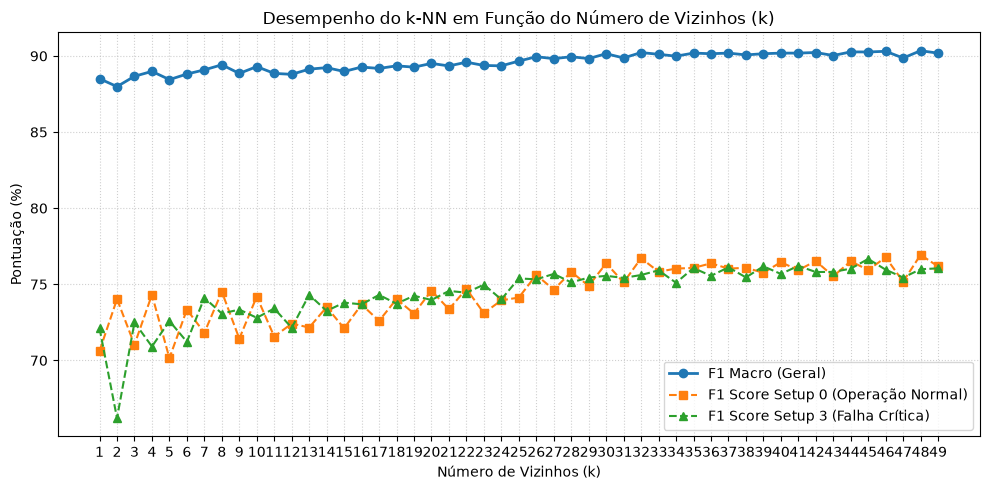

In [38]:
#Plotando o gráfico de F1 Score para cada Setup em função de k

plt.figure(figsize=(10, 5))
plt.plot(df_resultados_knn["k"], df_resultados_knn["F1 Macro"], marker='o', linewidth=2, label="F1 Macro (Geral)")
plt.plot(df_resultados_knn["k"], df_resultados_knn["F1 Score Setup 0"], marker='s', linestyle='--', label="F1 Score Setup 0 (Operação Normal)")
plt.plot(df_resultados_knn["k"], df_resultados_knn["F1 Score Setup 3"], marker='^', linestyle='--', label="F1 Score Setup 3 (Falha Crítica)")

plt.title("Desempenho do k-NN em Função do Número de Vizinhos (k)")
plt.xlabel("Número de Vizinhos (k)")
plt.ylabel("Pontuação (%)")
plt.xticks(k_values)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
#Definindo melhor valor de k com base no F1 Macro
df_resultados_knn.sort_values("F1 Macro", ascending=False).head(10)

,k,F1 Score Setup 0,F1 Score Setup 1,F1 Score Setup 2,F1 Score Setup 3,F1 Score Setup 4,Acurácia,F1 Macro,F1 Ponderado
47,48,76.938175,100.000000,99.296482,75.987842,99.503476,90.339321,90.345195,90.345195
45,46,76.771654,100.000000,99.296482,75.959596,99.503476,90.299401,90.306242,90.306242
43,44,76.511397,100.000000,99.296482,76.028084,99.503476,90.259481,90.267888,90.267888
44,45,75.939086,99.900299,99.296482,76.666667,99.503476,90.259481,90.261202,90.261202
41,42,76.528600,100.000000,99.296482,75.806452,99.503476,90.219561,90.227002,90.227002
31,32,76.712329,100.000000,99.296482,75.609756,99.503476,90.219561,90.224409,90.224409
34,35,76.076076,100.000000,99.296482,76.067527,99.503476,90.179641,90.188712,90.188712
36,37,76.028084,100.000000,99.296482,76.114965,99.503476,90.179641,90.188602,90.188602
40,41,75.931521,100.000000,99.296482,76.209279,99.503476,90.179641,90.188152,90.188152
39,40,76.453202,100.000000,99.296482,75.681130,99.503476,90.179641,90.186858,90.186858


In [42]:
# [Autoria: Claude] Funções criadas a partir da adaptação do código do SVM do APS1

def plotar_matrizes(modelos):
    for nome, modelo in modelos.items():
        predicted = cross_val_predict(modelo, X_df, Y_df, cv=20)
        cm = confusion_matrix(Y_df, predicted)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_setup)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(f"Matriz de Confusão - {nome}")
        plt.xticks(rotation=45)
        plt.show()
        
def plotar_roc(modelos, linhas, colunas, tamanho=(20, 10)):
    # Binarização das classes, pois a curva ROC é feita para problemas binários
    Y_bin = label_binarize(Y_df, classes=classes)
    plt.figure(figsize=tamanho)
    for indice, (nome, modelo) in enumerate(modelos.items()):
        plt.subplot(linhas, colunas, indice + 1)
        # Probabilidades obtidas por validação cruzada
        predicted_proba = cross_val_predict(modelo, X_df, Y_df, cv=20, method="predict_proba")
        for i, classe in enumerate(classes):
            fpr, tpr, _ = roc_curve(Y_bin[:, i], predicted_proba[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"Setup {int(classe)} (AUC = {roc_auc:.2f})")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.xlabel("Falso Positivo (FPR)")
        plt.ylabel("Verdadeiro Positivo (TPR)")
        plt.title(f"Curva ROC (OvR) - {nome}")
        plt.legend()
    plt.tight_layout()
    plt.show()


def plotar_aprendizado(modelos, linhas, colunas, tamanho=(20, 10)):
    plt.figure(figsize=tamanho)
    for indice, (nome, modelo) in enumerate(modelos.items()):
        plt.subplot(linhas, colunas, indice + 1)
        # shuffle=True porque o dataset está ordenado por setup
        train_sizes, train_scores, test_scores = learning_curve(
            modelo, X_df, Y_df, cv=20, scoring="accuracy", n_jobs=-1,
            train_sizes=np.linspace(0.3, 1.0, 5), shuffle=True, random_state=42
        )
        train_mean, train_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
        test_mean, test_std = np.mean(test_scores, axis=1), np.std(test_scores, axis=1)

        plt.title(f"Learning Curve - {nome}")
        plt.xlabel("Training examples")
        plt.ylabel("Score")
        plt.grid()
        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")
        plt.plot(train_sizes, train_mean, "o-", color="r", label="Training score")
        plt.plot(train_sizes, test_mean, "o-", color="g", label="Cross-validation score")
        plt.legend(loc="best")
    plt.tight_layout()
    plt.show()
    

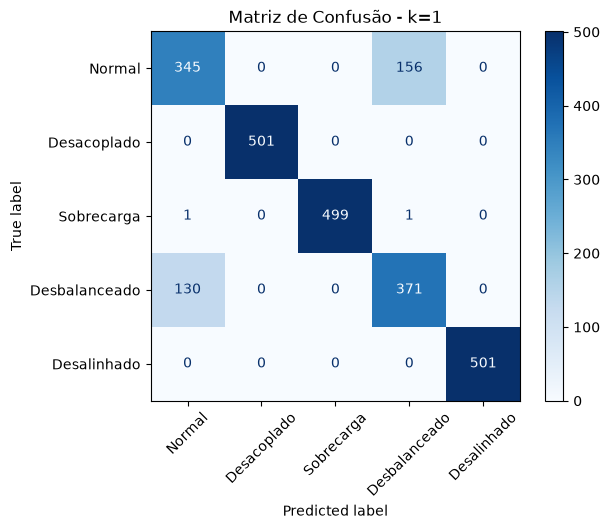

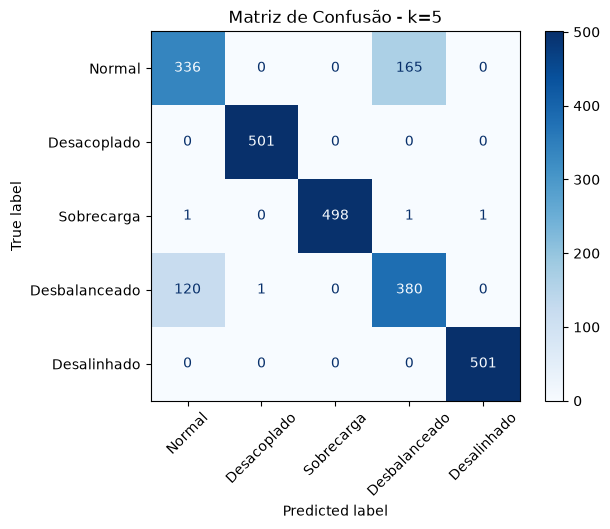

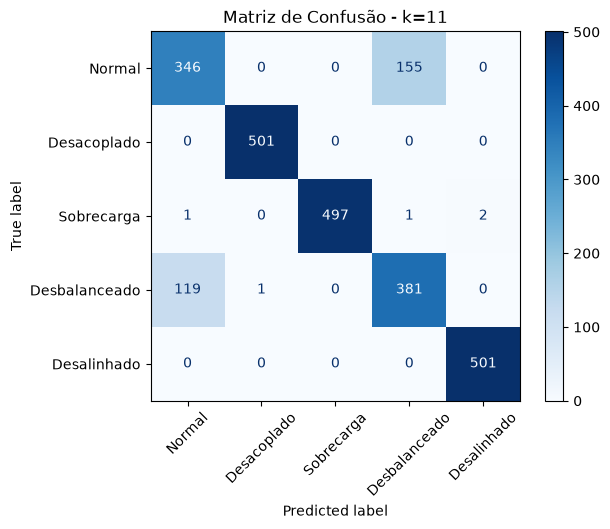

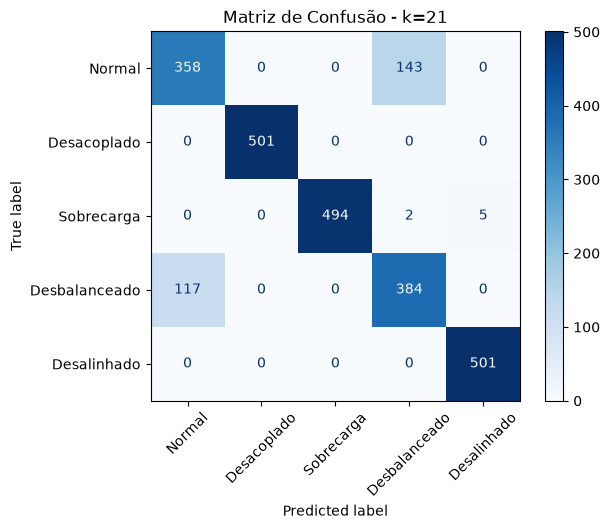

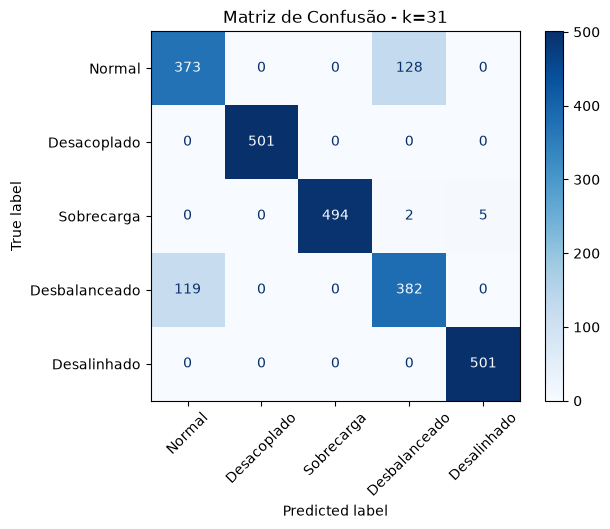

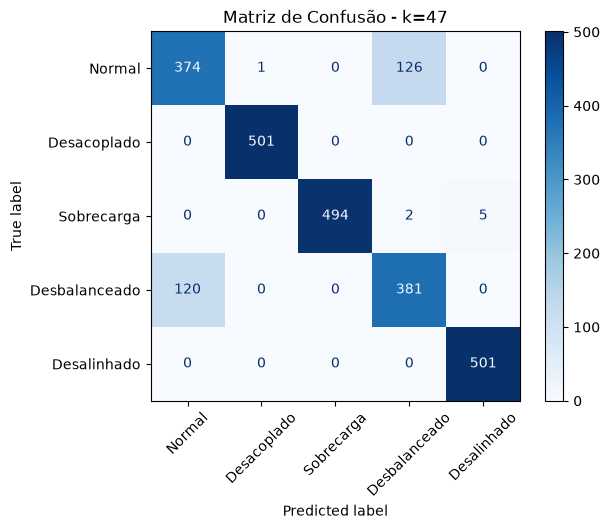

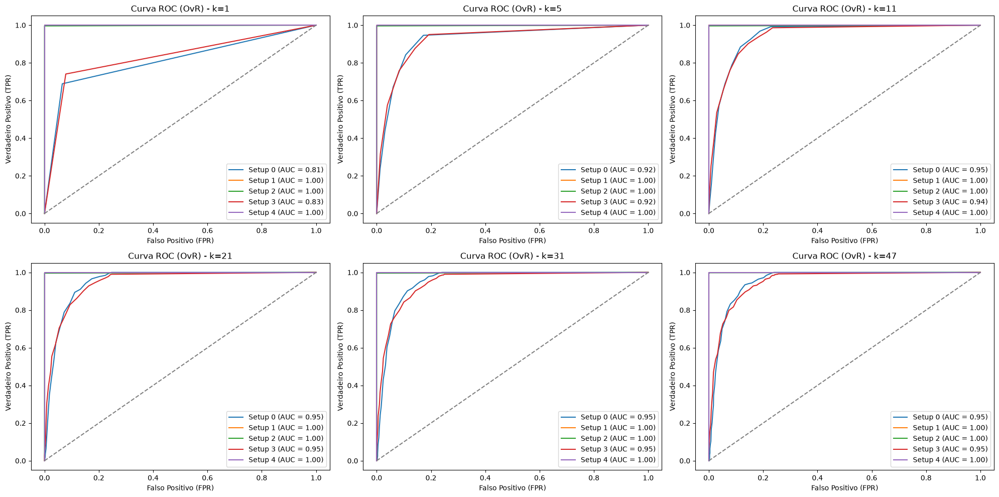

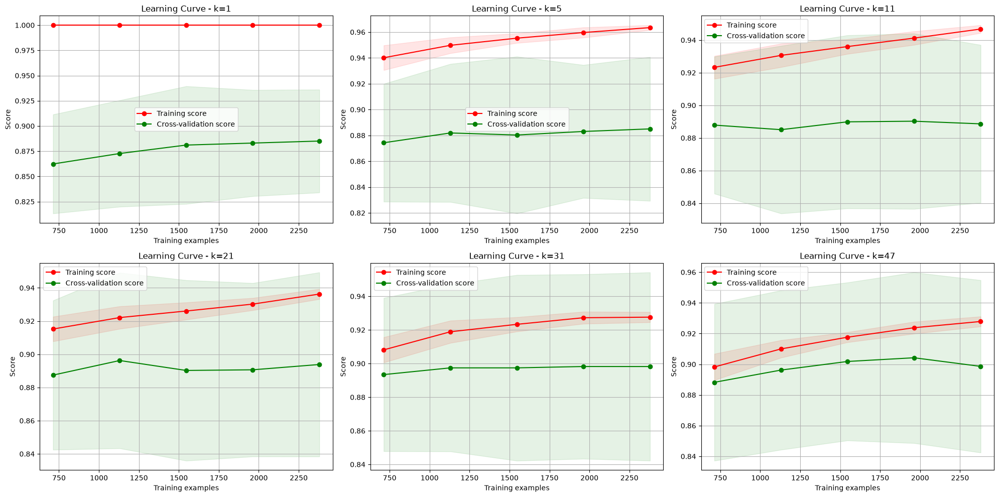

In [43]:
# Plotando o gráfico de Acurácia em função de k
# [Autoria: Claude] Dicionário de modelos KNN com diferentes valores de k
k = 37
modelos_knn_k = {f"k={k}": KNeighborsClassifier(n_neighbors=k) for k in [1, 5, 11, 21, 31, 47]}
        
plotar_matrizes(modelos_knn_k)
plotar_roc(modelos_knn_k, linhas=2, colunas=3)
plotar_aprendizado(modelos_knn_k, linhas=2, colunas=3)


In [44]:
k_escolhido = 31

# Métricas de distância a serem testadas
lista_metricas = ["euclidean", "manhattan", "chebyshev", "cosine"]

# Listas vazias para armazenar os resultados
metrica_list = []
f1_setupknn0 = []
f1_setupknn1 = []
f1_setupknn2 = []
f1_setupknn3 = []
f1_setupknn4 = []
acc_lista = []
f1_macroknn = []
f1_weightedknn = []

for metrica in lista_metricas:
    knn = KNeighborsClassifier(n_neighbors=k_escolhido, metric=metrica)
    y_pred_knn = cross_val_predict(knn, X_df, Y_df, cv=20)
    dic_relatorio = classification_report(Y_df, y_pred_knn, output_dict=True)

    metrica_list.append(metrica)
    f1_setupknn0.append(dic_relatorio["0.0"]["f1-score"] * 100)
    f1_setupknn1.append(dic_relatorio["1.0"]["f1-score"] * 100)
    f1_setupknn2.append(dic_relatorio["2.0"]["f1-score"] * 100)
    f1_setupknn3.append(dic_relatorio["3.0"]["f1-score"] * 100)
    f1_setupknn4.append(dic_relatorio["4.0"]["f1-score"] * 100)
    acc_lista.append(dic_relatorio["accuracy"] * 100)
    f1_macroknn.append(dic_relatorio["macro avg"]["f1-score"] * 100)
    f1_weightedknn.append(dic_relatorio["weighted avg"]["f1-score"] * 100)

df_resultados_knn_dist = pd.DataFrame({
    "Métrica": metrica_list,
    "F1 Score Setup 0": f1_setupknn0,
    "F1 Score Setup 1": f1_setupknn1,
    "F1 Score Setup 2": f1_setupknn2,
    "F1 Score Setup 3": f1_setupknn3,
    "F1 Score Setup 4": f1_setupknn4,
    "Acurácia": acc_lista,
    "F1 Macro": f1_macroknn,
    "F1 Ponderado": f1_weightedknn
})



In [45]:
df_resultados_knn_dist

,Métrica,F1 Score Setup 0,F1 Score Setup 1,F1 Score Setup 2,F1 Score Setup 3,F1 Score Setup 4,Acurácia,F1 Macro,F1 Ponderado
0,euclidean,75.125881,100.000000,99.296482,75.419546,99.503476,89.860279,89.869077,89.869077
1,manhattan,76.190476,100.000000,99.900100,76.817289,100.000000,90.578842,90.581573,90.581573
2,chebyshev,72.983871,99.009901,98.991935,72.817460,99.206349,88.622754,88.601903,88.601903
3,cosine,73.623188,96.038647,99.398798,71.367521,99.403579,88.143713,87.966347,87.966347


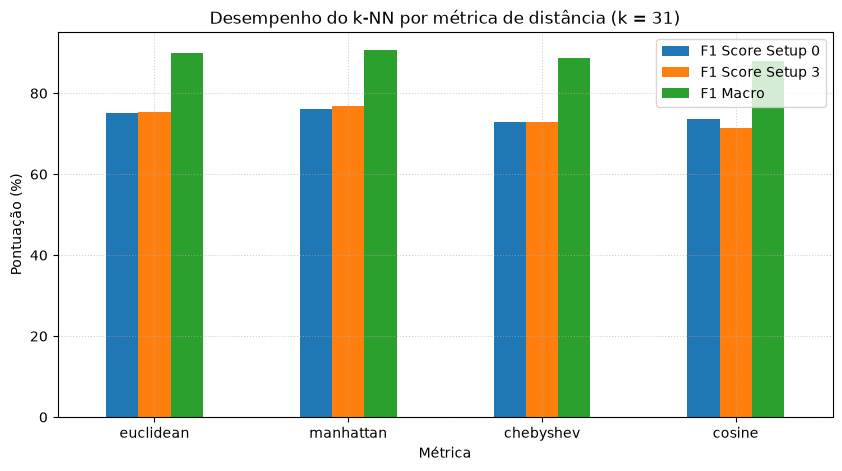

In [46]:
# [Autoria: Claude] Gráfico de barras comparando as métricas de distância
df_resultados_knn_dist.set_index("Métrica")[["F1 Score Setup 0", "F1 Score Setup 3", "F1 Macro"]].plot.bar(figsize=(10, 5), rot=0)
plt.ylabel("Pontuação (%)")
plt.title(f"Desempenho do k-NN por métrica de distância (k = {k_escolhido})")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

##### **3.2. Decision Tree**

O Decision Tree, assim como o KNN Classifier, é um dos tipos de algoritmo usados em Machine Learning usado para realizar classificações. Seu princípio, de forma muito resumida, se baseia em apresentar condicionais binários o qual são aplicados para cada entrada dentro do grupo de dados avaliados. Aqueles cujo atendam o condicional são separados em um grupo e, aqueles que não, em outro, criando-se então dois distintos grupos. Esse processo pode ser repetido indefinidamente até que haja a total separação dos grupos, mas há o risco de que o algoritmo treinado seja sucetível ao overfitting dependendo do caso. Por isso, é possível controlar parâmetros como o tamanho da árvore como também o grau de poda, o qual basicamente controla o balanço entre custo e complexidade do modelo. Um exemplo de como esse algoritmo funciona pode ser visto a seguir:

<p align="center">
  <img src="DecisionTree.png" alt="Texto Alternativo">
</p>

#### **3.2.1 Tamanho de Árvore**

Para ver como que a variação dos parâmetros mencionados influenciam no resultado, primeiro serão feitos modelos pensando no tamanho da árvore apenas para depois serem considerados os diferentes cpp_alphas, comparando o comportamento dos modelos através de seus respectivos classification_report, matriz de confusão, curva ROC e curva de aprendizado. Essa primeira etapa pode ser vista a seguir:

In [27]:
# Criação de lista com diferentes tamanhos de árvore a serem testados

lista_tamanhos = [1, 2, 5, 10, 15, 20, 25, 50]

# Criação de listas de controle para coleta apenas dos dados referentes ao F1 Score do classification_report visto que essa é nossa métrica de interesse

lista_setup0 = []
lista_setup1 = []
lista_setup2 = []
lista_setup3 = []
lista_setup4 = []
lista_accuracy = []
lista_macro_avg = []
lista_weighted_avg = []

# Loop que percorre todos os tamanhos de árvore definidos

for tamanho in lista_tamanhos:

    # Criaçao do algoritmo DecisionTreeClassifier com o tamanho definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

    decision_tree_origin = DecisionTreeClassifier(max_depth=tamanho, random_state=42)

    decision_tree_origin.fit(X_treino, y_treino)

    # Execução do cross validation com 20 folds

    predicted = cross_val_predict(decision_tree_origin, X_df, Y_df, cv = 20)

    # Criação do classification report em formato de dicionário para que seja possível extrair as informações de F1 Score mais facilmente

    dic_report = classification_report(Y_df, predicted, output_dict=True)

    # Coleta dos dados de interesse

    setup_0_f1 = dic_report["0.0"]["f1-score"] * 100
    setup_1_f1 = dic_report["1.0"]["f1-score"] * 100
    setup_2_f1 = dic_report["2.0"]["f1-score"] * 100
    setup_3_f1 = dic_report["3.0"]["f1-score"] * 100
    setup_4_f1 = dic_report["4.0"]["f1-score"] * 100
    accuracy = dic_report["accuracy"] * 100
    macro_avg_f1 = dic_report["macro avg"]["f1-score"] * 100
    weighted_avg_f1 = dic_report["weighted avg"]["f1-score"] * 100

    # Adição dos valores obtidos em suas respectivas listas de controle

    lista_setup0.append(setup_0_f1)
    lista_setup1.append(setup_1_f1)
    lista_setup2.append(setup_2_f1)
    lista_setup3.append(setup_3_f1)
    lista_setup4.append(setup_4_f1)
    lista_accuracy.append(accuracy)
    lista_macro_avg.append(macro_avg_f1)
    lista_weighted_avg.append(weighted_avg_f1)

# Criação de DataFrame para melhor visualização dos resultados entre diferentes tamanhos de árvore

df_resultados = pd.DataFrame({"Tamanho da Árvore": lista_tamanhos, 
                              "F1 Score Setup 0": lista_setup0, 
                              "F1 Score Setup 1": lista_setup1,
                              "F1 Score Setup 2": lista_setup2,
                              "F1 Score Setup 3": lista_setup3,
                              "F1 Score Setup 4": lista_setup4,
                              "Acurácia": lista_accuracy,
                              "Média Macro F1": lista_macro_avg,
                              "Média Ponderada F1": lista_weighted_avg})

df_resultados

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

,Tamanho da Árvore,F1 Score Setup 0,F1 Score Setup 1,F1 Score Setup 2,F1 Score Setup 3,F1 Score Setup 4,Acurácia,Média Macro F1,Média Ponderada F1
0,1,39.915966,97.336066,15.337423,0.000000,0.000000,39.920160,30.517891,30.517891
1,2,65.381968,100.000000,67.237687,8.665511,17.331023,60.758483,51.723238,51.723238
2,5,68.171558,100.000000,98.905473,74.509804,99.095477,88.263473,88.136462,88.136462
3,10,74.921956,100.000000,98.905473,77.363897,99.095477,90.059880,90.057361,90.057361
4,15,74.437628,100.000000,99.201597,76.116505,99.398798,89.820359,89.830905,89.830905
5,20,74.949084,100.000000,99.201597,76.413255,99.398798,89.980040,89.992547,89.992547
6,25,74.949084,100.000000,99.201597,76.413255,99.398798,89.980040,89.992547,89.992547
7,50,74.949084,100.000000,99.201597,76.413255,99.398798,89.980040,89.992547,89.992547



===== Tamanho de Árvore: 1 =====


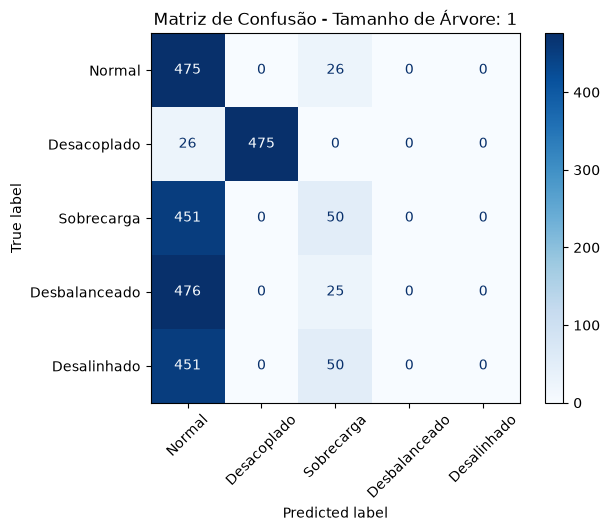


===== Tamanho de Árvore: 2 =====


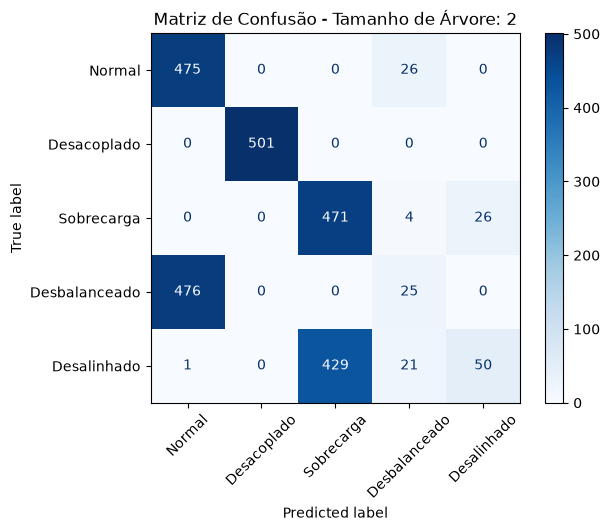


===== Tamanho de Árvore: 5 =====


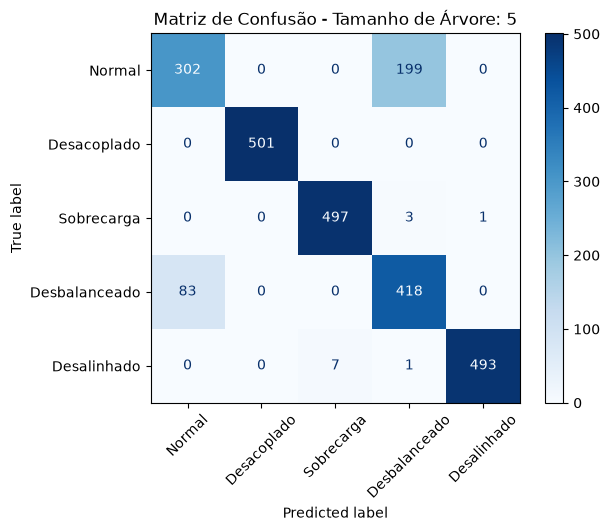


===== Tamanho de Árvore: 10 =====


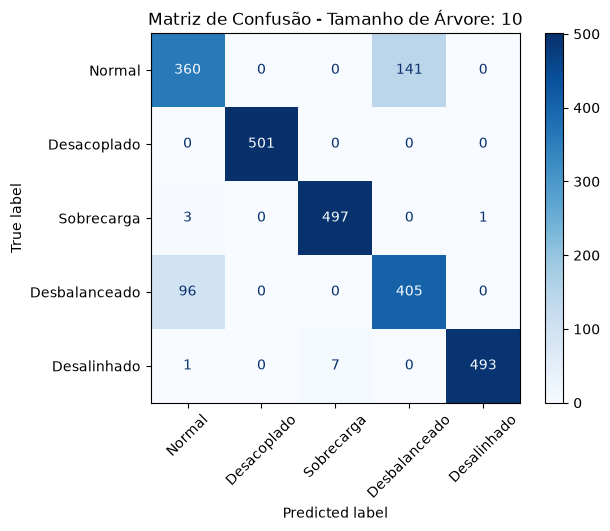


===== Tamanho de Árvore: 15 =====


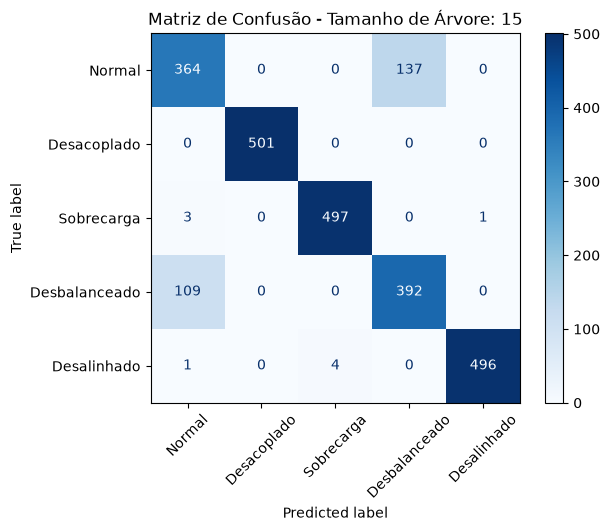


===== Tamanho de Árvore: 20 =====


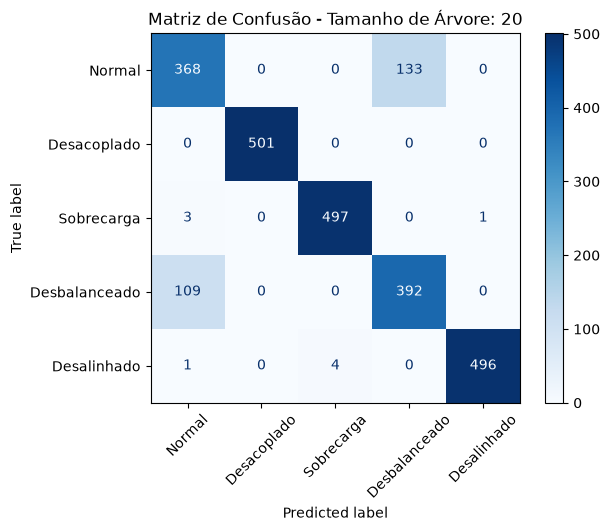


===== Tamanho de Árvore: 25 =====


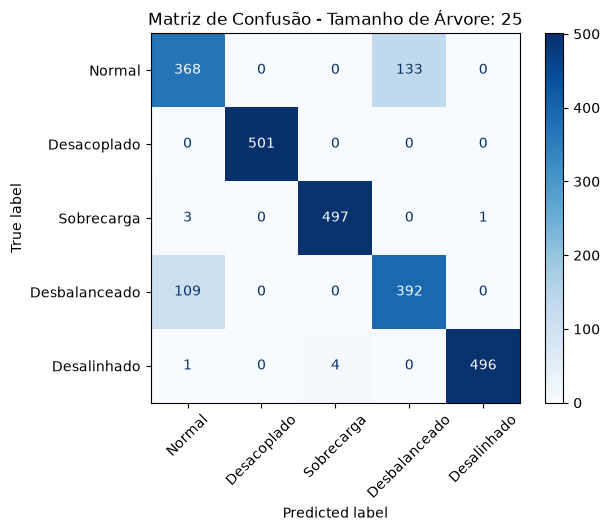


===== Tamanho de Árvore: 50 =====


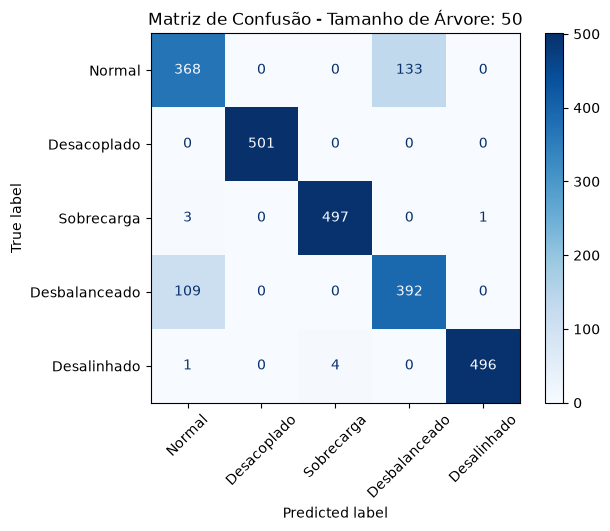

In [28]:
# Matrizes de confusão e relatórios de classificação

classes_setup = [
    "Normal",
    "Desacoplado",
    "Sobrecarga",
    "Desbalanceado",
    "Desalinhado"
]

for tamanho in lista_tamanhos:

    decision_tree_origin = DecisionTreeClassifier(max_depth=tamanho, random_state=42)

    decision_tree_origin.fit(X_treino, y_treino)

    predicted = cross_val_predict(decision_tree_origin, X_df, Y_df, cv=20)

    print(f"\n===== Tamanho de Árvore: {tamanho} =====")

    cm = confusion_matrix(Y_df, predicted)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes_setup
    )

    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusão - Tamanho de Árvore: {tamanho}")
    plt.xticks(rotation=45)
    plt.show()

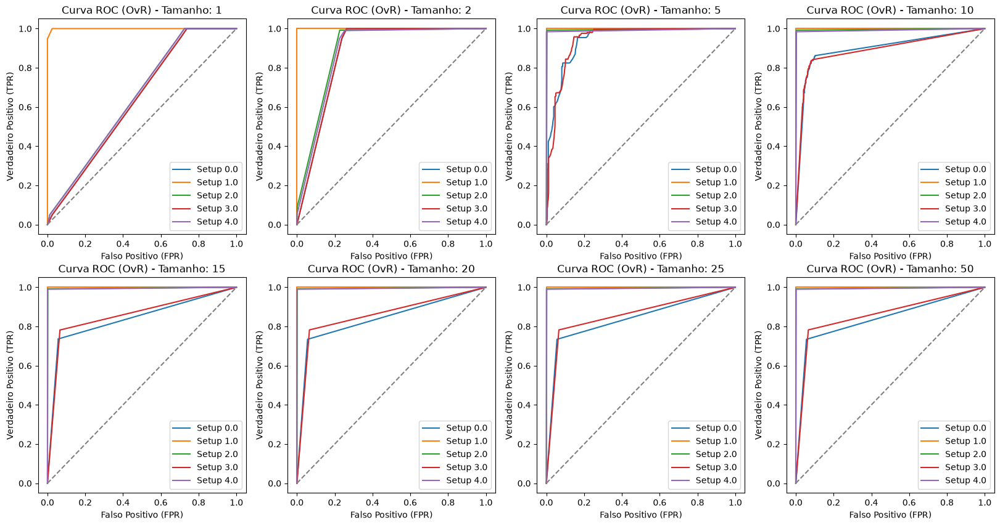

In [29]:
# Criação de lista com diferentes tamanhos de árvore a serem testados

lista_tamanhos = [1, 2, 5, 10, 15, 20, 25, 50]

# Lista das classes existentes

classes = [0.0, 1.0, 2.0, 3.0, 4.0]

# Criação de figura onde irão ser posicionados os gráficos de curvas ROC

plt.figure(figsize=(20, 10))

# Loop que percorre todos os tamanhos de árvore definidos

for tamanho in lista_tamanhos:

    # Criação de subplot para alocação do gráfico da curva ROC do tamanho de árvore analisado

    plt.subplot(2, 4, lista_tamanhos.index(tamanho) + 1)

    # Criaçao do algoritmo DecisionTreeClassifier com o tamanho definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

    decision_tree_origin = DecisionTreeClassifier(max_depth=tamanho, random_state=42)

    decision_tree_origin.fit(X_treino, y_treino)

    # Binarização das classes uma vez que a curva ROC é feita apenas com modelos binários

    Y_bin = label_binarize(Y_df, classes=classes)

    # Execução do cross validation com 20 folds com probabilidades o qual é importante para elaboração da curva ROC

    predicted_proba = cross_val_predict(decision_tree_origin, X_df, Y_df, cv = 20, method="predict_proba")

    # Loop que passa por cada classe para elaborar sua curva ROC

    for i, classe in enumerate(classes):

        # Execução da função de curva ROC da classe atual

        fpr, tpr, _ = roc_curve(Y_bin[:, i], predicted_proba[:, i])

        # Elaboração da curva ROC

        plt.plot(fpr, tpr, label=f"Setup {classe}")

    # Elaboração da curva ROC (continuação)

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Falso Positivo (FPR)")
    plt.ylabel("Verdadeiro Positivo (TPR)")
    plt.title(f"Curva ROC (OvR) - Tamanho: {tamanho}")
    plt.legend()

# Exibição da imagem

plt.show()

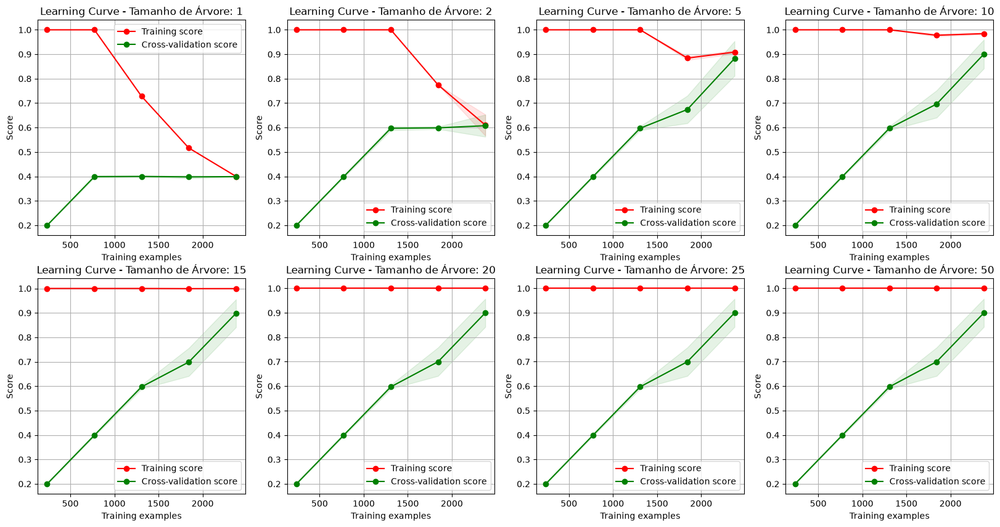

In [30]:
# Criação de lista com diferentes tamanhos de árvore a serem testados

lista_tamanhos = [1, 2, 5, 10, 15, 20, 25, 50]

# Criação de figura onde irão ser posicionados os gráficos de curvas ROC

plt.figure(figsize=(20, 10))

# Loop que percorre todos os tamanhos de árvore definidos

for tamanho in lista_tamanhos:

    # Criação de subplot para alocação do gráfico da curva ROC do tamanho de árvore analisado

    plt.subplot(2, 4, lista_tamanhos.index(tamanho) + 1)

    # Criaçao do algoritmo DecisionTreeClassifier com o tamanho definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

    decision_tree_origin = DecisionTreeClassifier(max_depth=tamanho, random_state=42)

    decision_tree_origin.fit(X_treino, y_treino)

    # Elaboração da curva de aprendizado 

    train_sizes, train_scores, test_scores = learning_curve(
        decision_tree_origin, X_df, Y_df, cv=20, scoring='accuracy', n_jobs=-1
    )

    # Média e desvio padrão do treino e teste
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Criação do gráfico da curva de aprendizado
    
    plt.title(f"Learning Curve - Tamanho de Árvore: {tamanho}")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")

# Exibição da imagem

plt.show()

Tendo os gráficos e as estatísticas presentes no classification_report, podemos realizar algumas conclusões:

**1.** Seguindo os dados provindos do classification_report, percebe-se uma melhora crescente do modelo que é refletido pelo F1-Score crescente. Entretanto, esse crescimento vem a cessar perto do tamanho de árvore 10 e, a partir desse ponto, as mudanças são quase inperceptíveis. Também é possível ver que a separação dos setups 1, 2 e 4 foram quase perfeitos, o que já se imaginava ser possível a partir das análises da matrix de confusão, gráfico de pares e boxplots, especialmente por conta dos parâmetros de vibração. Junto a isso, fica evidente que os setups 0 e 3 são deveras atrelados, por isso a capacidade de classificação dos mesmos foi prejudicada;

**3.** Pelas matrizes de confusão, fica evidente que, enquanto os setups 1, 2 e 4 são melhores classificados com maiores tamanhos de árvore, a separação entre setup 0 e 3 são conflituosas entre si. No caso em que se está trabalhando, ter um motor classificado como desalinhado (setup 3) quando ele está normal apenas aciona uma medida de prevenção a qual desencadearia uma revisão por um técnico. O que deve se atentar é se o contrário acontece, visto que, caso um motor desalinhado não seja detectado, existe um grande risco de que ele quebre no futuro próximo, o que desencadearia enormes custos, então, visto essa situação, é melhor observar modelos que possuem um melhor f1 score no setup 3;

**3.** Observando a curva ROC, a melhora dos modelos conforme se aumenta o tamanho da árvore fica mais visual: é possível ver as curvas ROC das classes 1, 2 e 4 alcançam o pico de 100% de Verdadeiros Positivos (VP) sem quase nenhuma ocorrência de falsos positivos já com tamanho de árvore 5. Entretanto, assim como previsto na matriz de confusão, devido a um grau de semelhança, as classes 0 e 3 conseguem alcançar esse mesmo pico com tamanho de árvore 5 apenas quando se obtêm aproximadamente 25% de Falsos Positivos (FP), o que, considerando a quantidade de dados presentes, é uma quantidade considerável. Já no tamanho de árvore 10, a curva das duas últimas classes muda e oferece mais de 80% de VP em troca de apenas 10% de FP. A partir desse ponto, no entanto, essa troca apenas piora;

**4.** Por fim, observando a curva de aprendizado, fica evidente também que, quanto maior a árvore, melhor o a curva de aprendizado resultante. Entretanto, a partir do tamanho 15, o crescimento estagna. Além disso, mesmo que a curva não tenha saturado uma vez que não se tem dados suficientes para tal, isso não é um problema uma vez que os resultados de teste já alcançam notas próximos a 90%.

Usando de todas as informações previamente ditas e buscando um modelo que ofereça um bom trade-off de desempenho considerando a aparente dificuldade de separação dos setups 0 e 3, decidiu-se adotar o **tamanho de árvore 15**, o qual aparenta ser o último ponto de melhora do modelo anterior à sua estagnação.

#### **3.2.2 - CCP Alpha**

Definido o tamanho de árvore adequado, podemos partir para avaliação do CCP Alpha que dita o balanço entre custo e complexidade do modelo de classificação. O mesmo processo elaborado previamente será repitido nessa seção, porém, com a diferença que serão testados diferentes valores de CCP Alpha:

In [31]:
# Criação de listas de controle para coleta apenas dos dados referentes ao F1 Score do classification_report visto que essa é nossa métrica de interesse

lista_setup0 = []
lista_setup1 = []
lista_setup2 = []
lista_setup3 = []
lista_setup4 = []
lista_accuracy = []
lista_macro_avg = []
lista_weighted_avg = []

# Criaçao do algoritmo DecisionTreeClassifier com o tamanho definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

decision_tree_origin = DecisionTreeClassifier(max_depth=15, random_state=42)

decision_tree_origin.fit(X_treino, y_treino)

# Geração dos diferentes valores de alpha

path = decision_tree_origin.cost_complexity_pruning_path(X_df, Y_df)
ccp_alphas = path.ccp_alphas

print(len(ccp_alphas))

# Listas para filtrar a quantidade de alphas

lista_indexes = [0, 7, 14, 21, 28, 33, 38, 45, 51, 57, 62]
lista_alphas = []

# Filtro da quantidade de alphas

for i in lista_indexes:

    lista_alphas.append(ccp_alphas[i])

# Loop que percorre todos os valores de alpha

for alpha in lista_alphas:

    # Criaçao do algoritmo DecisionTreeClassifier com o alpha definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

    decision_tree_alpha = DecisionTreeClassifier(max_depth=15, ccp_alpha=alpha, random_state=42)

    decision_tree_alpha.fit(X_treino, y_treino)

    # Execução do cross validation com 20 folds

    predicted = cross_val_predict(decision_tree_alpha, X_df, Y_df, cv = 20)

    # Criação do classification report em formato de dicionário para que seja possível extrair as informações de F1 Score mais facilmente

    dic_report = classification_report(Y_df, predicted, output_dict=True)

    # Coleta dos dados de interesse

    setup_0_f1 = dic_report["0.0"]["f1-score"] * 100
    setup_1_f1 = dic_report["1.0"]["f1-score"] * 100
    setup_2_f1 = dic_report["2.0"]["f1-score"] * 100
    setup_3_f1 = dic_report["3.0"]["f1-score"] * 100
    setup_4_f1 = dic_report["4.0"]["f1-score"] * 100
    accuracy = dic_report["accuracy"] * 100
    macro_avg_f1 = dic_report["macro avg"]["f1-score"] * 100
    weighted_avg_f1 = dic_report["weighted avg"]["f1-score"] * 100

    # Adição dos valores obtidos em suas respectivas listas de controle

    lista_setup0.append(setup_0_f1)
    lista_setup1.append(setup_1_f1)
    lista_setup2.append(setup_2_f1)
    lista_setup3.append(setup_3_f1)
    lista_setup4.append(setup_4_f1)
    lista_accuracy.append(accuracy)
    lista_macro_avg.append(macro_avg_f1)
    lista_weighted_avg.append(weighted_avg_f1)

# Criação de DataFrame para melhor visualização dos resultados entre diferentes tamanhos de árvore

df_resultados = pd.DataFrame({"Alphas": lista_alphas, 
                            "F1 Score Setup 0": lista_setup0, 
                            "F1 Score Setup 1": lista_setup1,
                            "F1 Score Setup 2": lista_setup2,
                            "F1 Score Setup 3": lista_setup3,
                            "F1 Score Setup 4": lista_setup4,
                            "Acurácia": lista_accuracy,
                            "Média Macro F1": lista_macro_avg,
                            "Média Ponderada F1": lista_weighted_avg})

df_resultados

63


,Alphas,F1 Score Setup 0,F1 Score Setup 1,F1 Score Setup 2,F1 Score Setup 3,F1 Score Setup 4,Acurácia,Média Macro F1,Média Ponderada F1
0,0.000000,74.437628,100.00000,99.201597,76.116505,99.398798,89.820359,89.830905,89.830905
1,0.000394,74.437628,100.00000,99.201597,76.116505,99.398798,89.820359,89.830905,89.830905
2,0.000599,74.385246,100.00000,99.201597,76.162791,99.398798,89.820359,89.829686,89.829686
3,0.000767,73.858921,100.00000,99.201597,76.245211,99.398798,89.740519,89.740905,89.740905
4,0.001331,73.346693,100.00000,99.201597,74.059406,99.398798,89.181637,89.201299,89.201299
5,0.001500,74.081430,100.00000,99.201597,74.325674,99.398798,89.381238,89.401500,89.401500
6,0.002017,74.677259,100.00000,99.201597,74.725275,99.398798,89.580838,89.600586,89.600586
7,0.002860,75.733855,100.00000,99.201597,75.050710,99.398798,89.860279,89.876992,89.876992
8,0.003993,74.975075,100.00000,99.201597,74.626866,99.398798,89.620758,89.640467,89.640467
9,0.008723,70.967742,100.00000,99.201597,69.441624,99.398798,87.784431,87.801952,87.801952



===== Tamanho de Árvore: 15 / Alpha: 0.0 =====


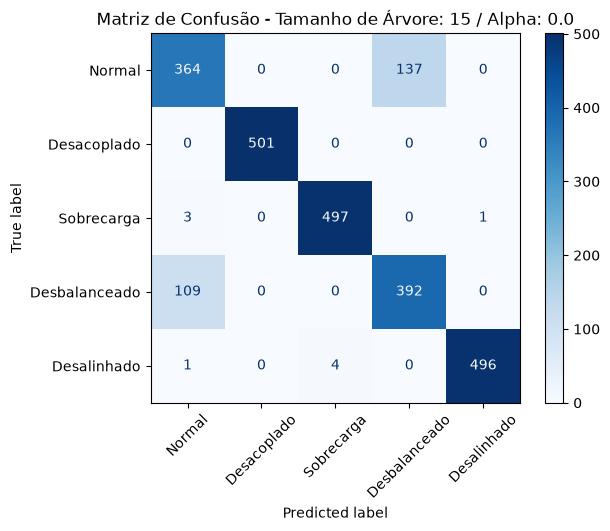


===== Tamanho de Árvore: 15 / Alpha: 0.0003940836276165626 =====


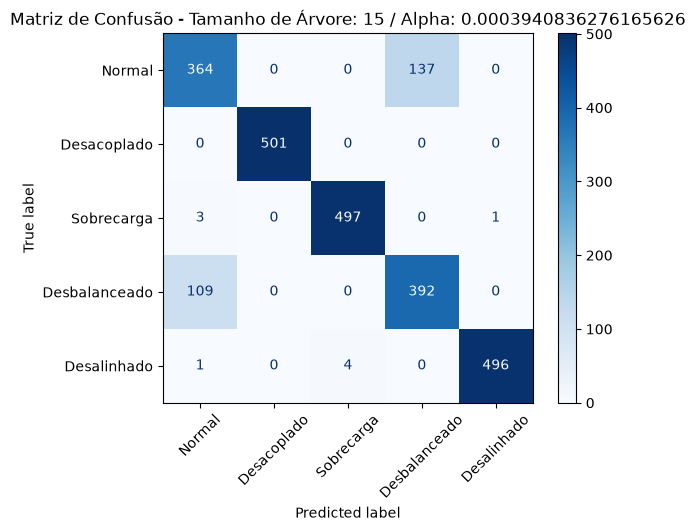


===== Tamanho de Árvore: 15 / Alpha: 0.0005988023952095808 =====


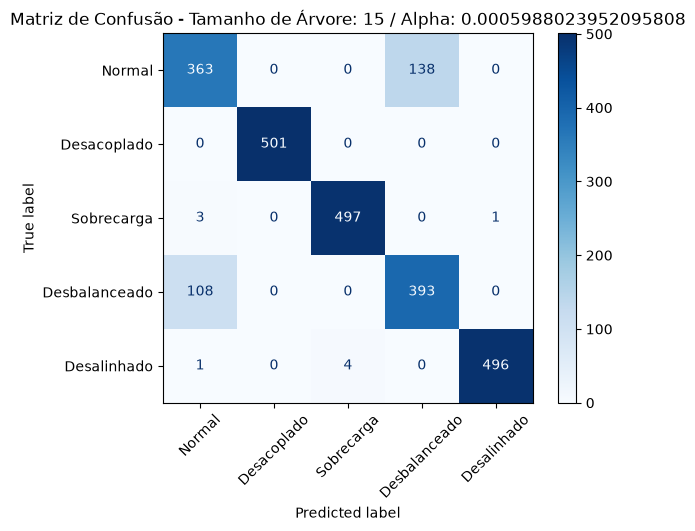


===== Tamanho de Árvore: 15 / Alpha: 0.0007667205271995696 =====


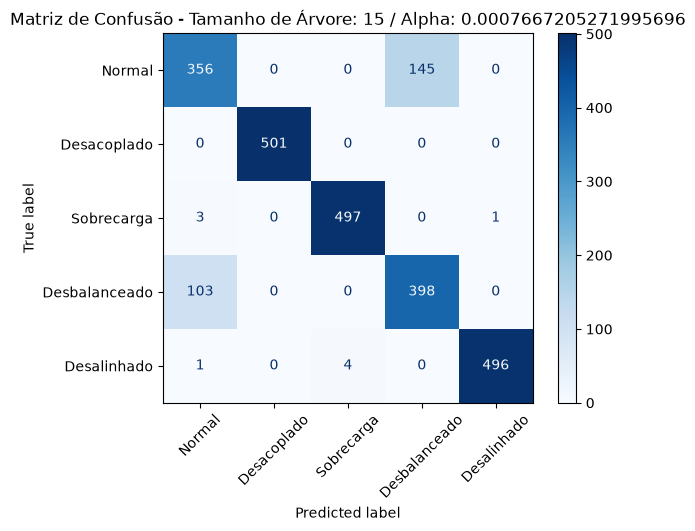


===== Tamanho de Árvore: 15 / Alpha: 0.0013306719893546241 =====


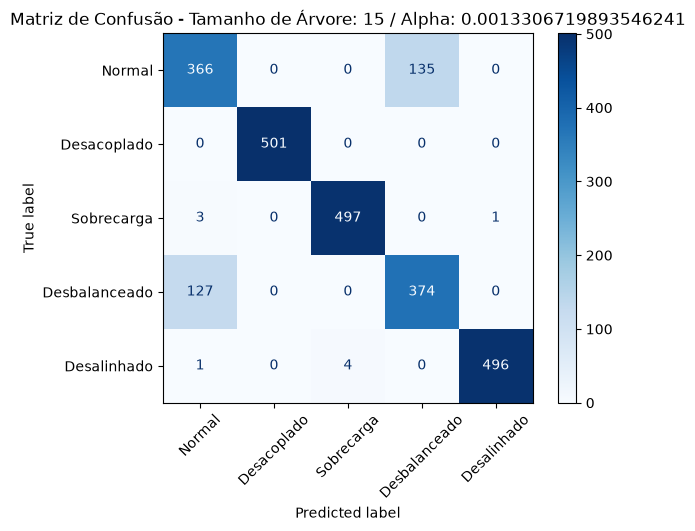


===== Tamanho de Árvore: 15 / Alpha: 0.001500030242545212 =====


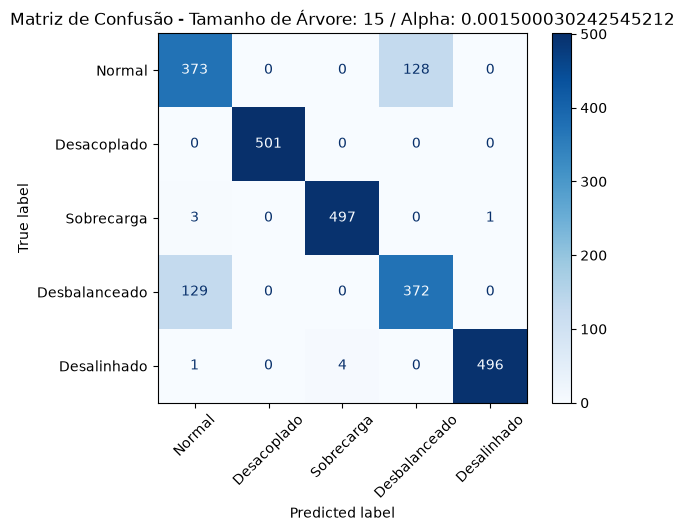


===== Tamanho de Árvore: 15 / Alpha: 0.0020170185943901675 =====


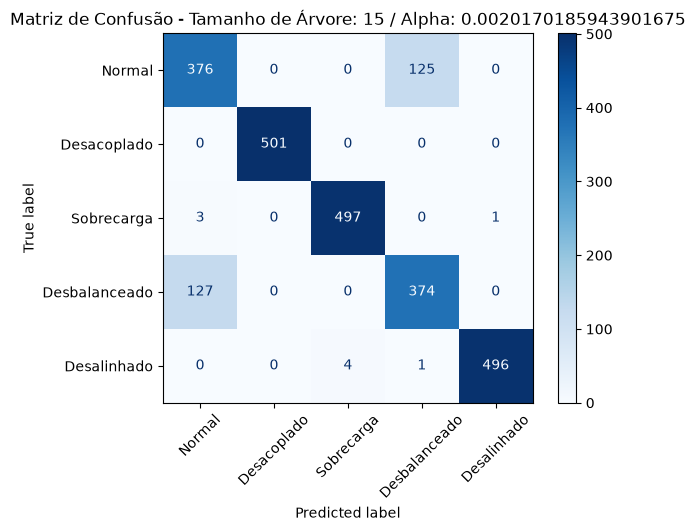


===== Tamanho de Árvore: 15 / Alpha: 0.002859516506640864 =====


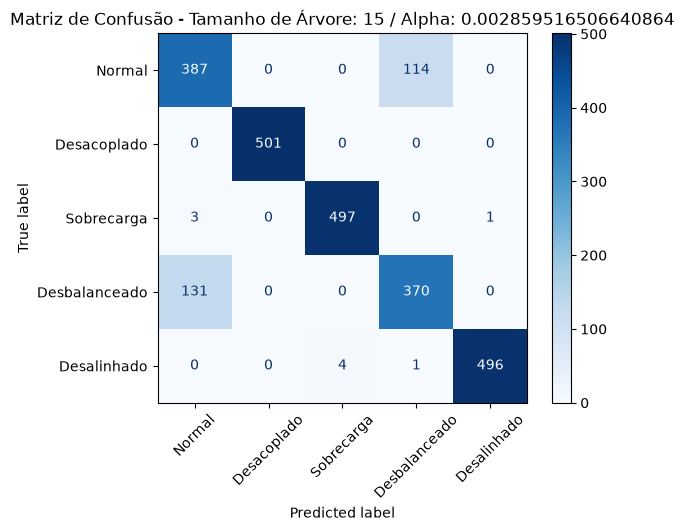


===== Tamanho de Árvore: 15 / Alpha: 0.00399270722624016 =====


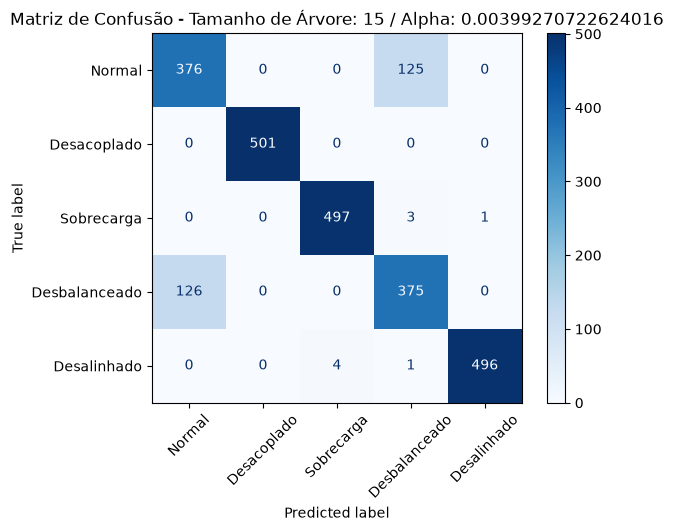


===== Tamanho de Árvore: 15 / Alpha: 0.008723355764155352 =====


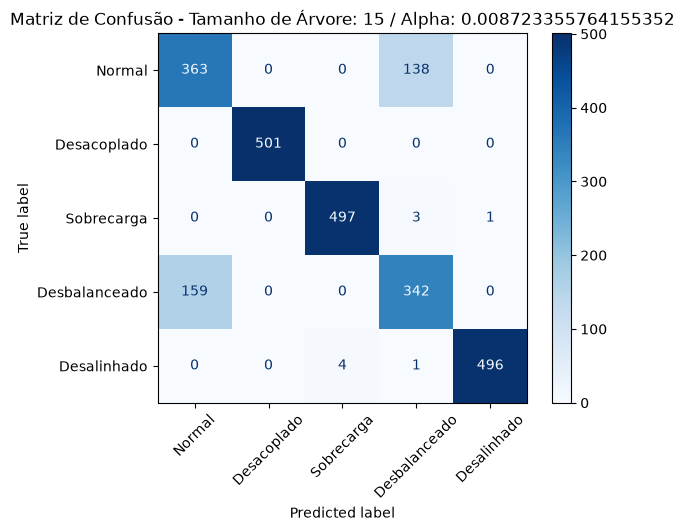


===== Tamanho de Árvore: 15 / Alpha: 0.20000000000000007 =====


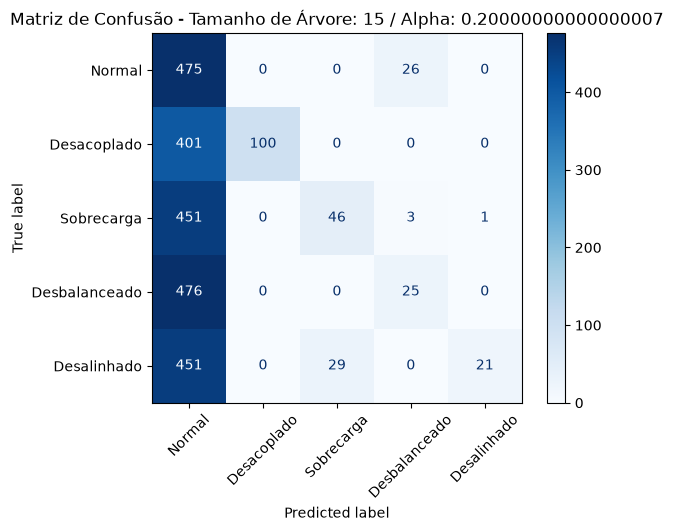

In [32]:
# Matrizes de confusão e relatórios de classificação

classes_setup = [
    "Normal",
    "Desacoplado",
    "Sobrecarga",
    "Desbalanceado",
    "Desalinhado"
]

decision_tree_origin = DecisionTreeClassifier(max_depth=15, random_state=42)

decision_tree_origin.fit(X_treino, y_treino)

path = decision_tree_origin.cost_complexity_pruning_path(X_df, Y_df)
ccp_alphas = path.ccp_alphas

lista_indexes = [0, 7, 14, 21, 28, 33, 38, 45, 51, 57, 62]
lista_alphas = []

# Filtro da quantidade de alphas

for i in lista_indexes:

    lista_alphas.append(ccp_alphas[i])

for alpha in lista_alphas:

    decision_tree_alpha = DecisionTreeClassifier(max_depth=15, ccp_alpha=alpha, random_state=42)

    decision_tree_alpha.fit(X_treino, y_treino)

    predicted = cross_val_predict(decision_tree_alpha, X_df, Y_df, cv=20)

    print(f"\n===== Tamanho de Árvore: 15 / Alpha: {alpha} =====")

    cm = confusion_matrix(Y_df, predicted)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes_setup
    )

    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusão - Tamanho de Árvore: 15 / Alpha: {alpha}")
    plt.xticks(rotation=45)
    plt.show()

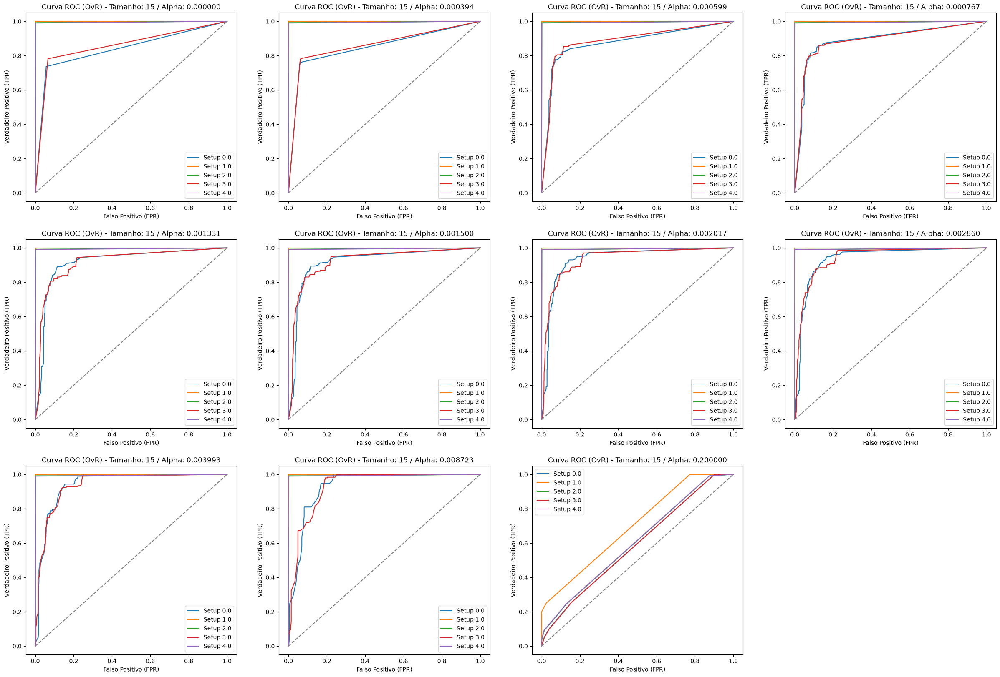

In [33]:
# Lista das classes existentes

classes = [0.0, 1.0, 2.0, 3.0, 4.0]

# Criação de figura onde irão ser posicionados os gráficos de curvas ROC

plt.figure(figsize=(30, 20))

# Criaçao do algoritmo DecisionTreeClassifier com o tamanho definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

decision_tree_origin = DecisionTreeClassifier(max_depth=15, random_state=42)

decision_tree_origin.fit(X_treino, y_treino)

# Geração dos diferentes valores de alpha

path = decision_tree_origin.cost_complexity_pruning_path(X_df, Y_df)
ccp_alphas = path.ccp_alphas

# Listas para filtrar a quantidade de alphas

lista_indexes = [0, 7, 14, 21, 28, 33, 38, 45, 51, 57, 62]
lista_alphas = []

# Filtro da quantidade de alphas

for i in lista_indexes:

    lista_alphas.append(ccp_alphas[i])

# Loop que percorre todos os valores de alpha

for alpha in lista_alphas:

    # Criação de subplot para alocação do gráfico da curva ROC do alpha analisado

    plt.subplot(3, 4, lista_alphas.index(alpha) + 1)

    # Criaçao do algoritmo DecisionTreeClassifier com o alpha definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

    decision_tree_alpha = DecisionTreeClassifier(max_depth=15, ccp_alpha=alpha, random_state=42)

    decision_tree_alpha.fit(X_treino, y_treino)

    # Binarização das classes uma vez que a curva ROC é feita apenas com modelos binários

    Y_bin = label_binarize(Y_df, classes=classes)

    # Execução do cross validation com 20 folds com probabilidades o qual é importante para elaboração da curva ROC

    predicted_proba = cross_val_predict(decision_tree_alpha, X_df, Y_df, cv = 20, method="predict_proba")

    # Loop que passa por cada classe para elaborar sua curva ROC

    for i, classe in enumerate(classes):

        # Execução da função de curva ROC da classe atual

        fpr, tpr, _ = roc_curve(Y_bin[:, i], predicted_proba[:, i])

        # Elaboração da curva ROC

        plt.plot(fpr, tpr, label=f"Setup {classe}")

    # Elaboração da curva ROC (continuação)

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Falso Positivo (FPR)")
    plt.ylabel("Verdadeiro Positivo (TPR)")
    plt.title(f"Curva ROC (OvR) - Tamanho: 15 / Alpha: {alpha:.6f}")
    plt.legend()

# Exibição da imagem

plt.show()

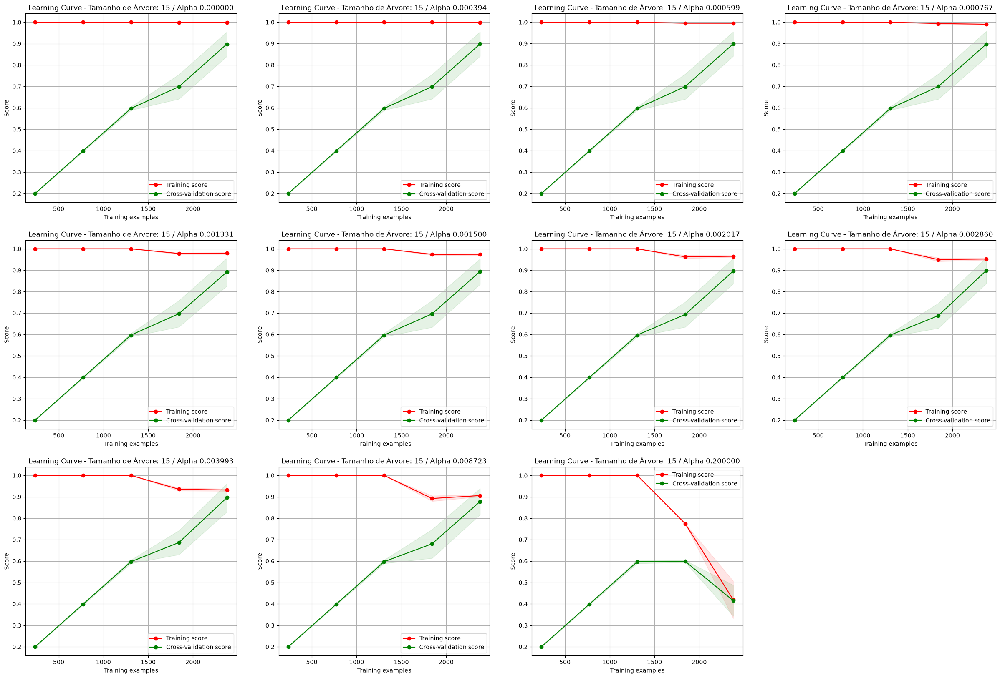

In [34]:
# Criação de figura onde irão ser posicionados os gráficos de curva de crescimento

plt.figure(figsize=(30, 20))

# Criaçao do algoritmo DecisionTreeClassifier com o tamanho definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

decision_tree_origin = DecisionTreeClassifier(max_depth=15, random_state=42)

decision_tree_origin.fit(X_treino, y_treino)

# Geração dos diferentes valores de alpha

path = decision_tree_origin.cost_complexity_pruning_path(X_df, Y_df)
ccp_alphas = path.ccp_alphas

# Listas para filtrar a quantidade de alphas

lista_indexes = [0, 7, 14, 21, 28, 33, 38, 45, 51, 57, 62]
lista_alphas = []

# Filtro da quantidade de alphas

for i in lista_indexes:

    lista_alphas.append(ccp_alphas[i])

# Loop que percorre todos os valores de alpha

for alpha in lista_alphas:

    # Criação de subplot para alocação do gráfico da curva de crescimento do alpha de árvore analisado

    plt.subplot(3, 4, lista_alphas.index(alpha) + 1)

    # Criaçao do algoritmo DecisionTreeClassifier com o alpha definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

    decision_tree_alpha = DecisionTreeClassifier(max_depth=15, ccp_alpha=alpha, random_state=42)

    decision_tree_alpha.fit(X_treino, y_treino)

    # Elaboração da curva de aprendizado 

    train_sizes, train_scores, test_scores = learning_curve(
        decision_tree_alpha, X_df, Y_df, cv=20, scoring='accuracy', n_jobs=-1
    )

    # Média e desvio padrão do treino e teste
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Criação do gráfico da curva de aprendizado
    
    plt.title(f"Learning Curve - Tamanho de Árvore: 15 / Alpha {alpha:.6f}")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")

# Exibição da imagem

plt.show()

Tendo os gráficos e as estatísticas presentes no classification_report, podemos realizar algumas conclusões:

**1.** Segundo o classification_report, fora os alphas de alto valor, todos os outros modelos apresentam valor médio extremamente parecido. O que mais varia entre todas as tentativas é a classificação dos setups 0 e 3, os quais apresentam valores de F1 Score diferentes dependendo do alpha utilizado. Entre todos os resultados, os mais promissores foram os alphas 0.000745 e 0.002831, pois eles apresentam os melhores valores de F1 Score dos setups 3 e 0, respectivamente, sem sacrificar o outro setup;

**2.** Nas matrizes de confusão, se reinforça a ideia de que o incremento de alpha até certo ponto oferece melhores resultados de F1 Score, especialmente o valor de 0.002831, esse em que se encontra a menor quantidade de classificações erradas de motores desalinhados para normais;

**2.** Referente às curvas ROC, são as curvas dos setup 0 e 3 que são as mais problemáticas, apresentando o mesmo comportamento do que foi visto na variação do tamanho de árvore, porém, existe a degradação do modelo conforme se usa de alphas muito altos;

**3.** Por fim, segundo as curvas de crescimento, se vê um comportamento bem similar entre os alphas e também, assim como visto nas curvas ROC, existe um decaimento da curva de crescimento nos valores altos de ccp_alpha, o que pode ser explicado pelo fato que, adotando uma poda mais agressiva, pode-se perder informações relevantes no processo os quais diminuem o desempenho do modelo;

Usando de todas as informações previamente ditas e buscando um modelo que ofereça um melhor trade-off de desempenho considerando a aparente dificuldade de separação dos setups 0 e 3 já previamente apresentado, decidiu-se adotar o **ccp_alpha de 0.002831**, gerando uma **média de aproximadamente 90% de F1 Score do modelo** junto do tamanho de árvore previamente estabelecido. 

##### **3.3. SVM**

O modelo SVM (Support Vector Machine) é um método de aprendizado de máquina baseado em otimização, que busca a maximização da margem de separação de exemplos de diferentes classes, tendo como objetivo encontrar um hiperplano que melhor separa as classes no espaço de caracterísicas (features), considerando ótimo o hiperplano que maximiza a margem entre duas classes. A margem é a distância entre o hiperplano e os pontos mais próximos de cada classe. Esses pontos próximos são chamados de vetores de suporte.

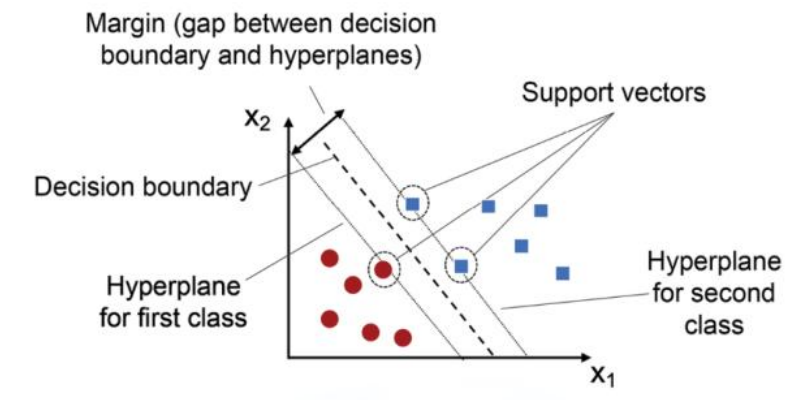

Nesta atividade, serão analizados dois tipos de análise SVM:

**1.** O modelo SVM Linear procura separar as cinco classes por hiperplanos lineares. Em termos simples, ele verifica se é possível distinguir os setups com “linhas retas” no espaço formado pelos oito atributos.

**2.** O SVM RBF usa uma função de kernel gaussiana. Esse kernel permite que o modelo construa regiões de decisão mais complexas. Ele é útil caso a separação entre os tipos de falha não seja linear, cenário plausível porque os sinais de corrente, potência e vibração podem se relacionar de modo não linear.

Primeiramente foram testados diversos valores de C (parâmetro que controla a penalização dos erros de classificação no SVM), para testar e escolher o melhor valor para o modelo

In [35]:
# Teste de diferentes valores de C nos modelos SVM

lista_c = [0.01, 0.1, 1, 10, 100]

lista_kernel = []
lista_valor_c = []
lista_setup0 = []
lista_setup1 = []
lista_setup2 = []
lista_setup3 = []
lista_setup4 = []
lista_accuracy = []
lista_macro_avg = []
lista_weighted_avg = []

for kernel in ["linear", "rbf"]:

    for valor_c in lista_c:

        modelo_svm = SVC(
            kernel=kernel,
            C=valor_c,
            probability=True,
            random_state=42
        )

        modelo_svm.fit(X_treino, y_treino)

        predicted = cross_val_predict(
            modelo_svm,
            X_df,
            Y_df,
            cv=20
        )

        dic_report = classification_report(
            Y_df,
            predicted,
            output_dict=True
        )

        lista_kernel.append(kernel)
        lista_valor_c.append(valor_c)
        lista_setup0.append(dic_report["0.0"]["f1-score"] * 100)
        lista_setup1.append(dic_report["1.0"]["f1-score"] * 100)
        lista_setup2.append(dic_report["2.0"]["f1-score"] * 100)
        lista_setup3.append(dic_report["3.0"]["f1-score"] * 100)
        lista_setup4.append(dic_report["4.0"]["f1-score"] * 100)
        lista_accuracy.append(dic_report["accuracy"] * 100)
        lista_macro_avg.append(dic_report["macro avg"]["f1-score"] * 100)
        lista_weighted_avg.append(
            dic_report["weighted avg"]["f1-score"] * 100
        )

df_resultados_svm_c = pd.DataFrame({
    "Kernel": lista_kernel,
    "C": lista_valor_c,
    "F1 Score Setup 0": lista_setup0,
    "F1 Score Setup 1": lista_setup1,
    "F1 Score Setup 2": lista_setup2,
    "F1 Score Setup 3": lista_setup3,
    "F1 Score Setup 4": lista_setup4,
    "Acurácia": lista_accuracy,
    "Média Macro F1": lista_macro_avg,
    "Média Ponderada F1": lista_weighted_avg
})

df_resultados_svm_c

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\

KeyboardInterrupt: 

Observando a tabela, pode-se observar que a média macro F1 apresenta melhores resultados com C=10, tanto co caso do Kenel linear quanto rbf, e passa a cair levemente depois deste ponto. Sendo assim os testes de SVM serão realizados considerando um C=10.

In [ ]:
# Treinar modelos SVM

# Modelo com kernel linear
svm_linear = SVC(kernel='linear', C=10, probability=True, random_state=42)

# Modelo com kernel RBF
svm_rbf = SVC(kernel='rbf', C=10, probability=True, random_state=42)

# Dicionário com os modelos definidos

modelos_svm = {
    "SVM Linear": svm_linear,
    "SVM RBF": svm_rbf,
}

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\


===== SVM Linear =====


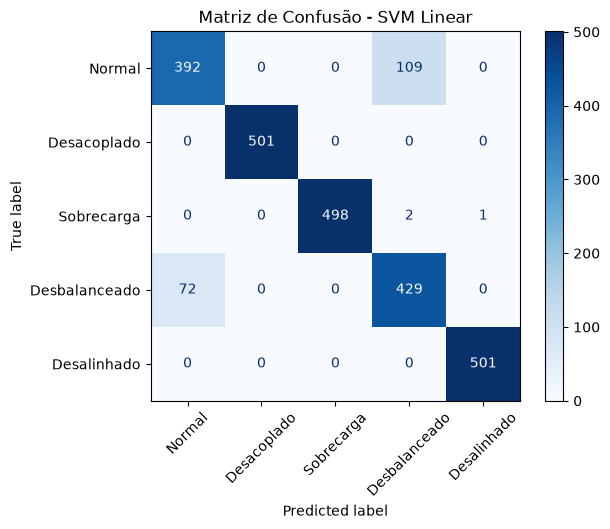

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\


===== SVM RBF =====


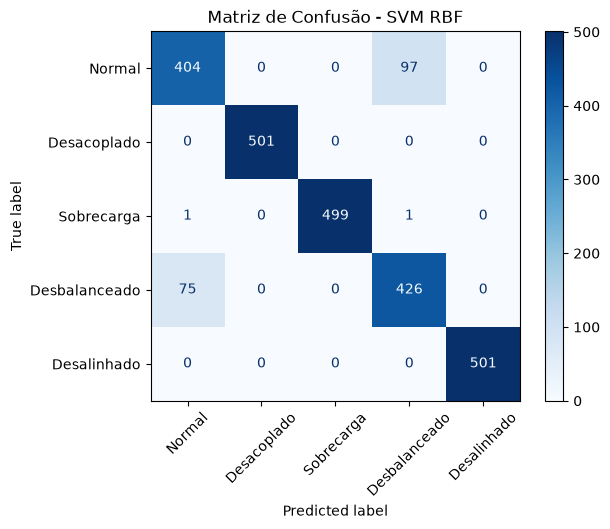

In [ ]:
# Matrizes de confusão 

# Classes do problema

classes_setup = [
    "Normal",
    "Desacoplado",
    "Sobrecarga",
    "Desbalanceado",
    "Desalinhado"
]


for nome, modelo in modelos_svm.items():

    modelo.fit(X_treino, y_treino)

    # Execução do cross validation
    predicted = cross_val_predict(modelo, X_df, Y_df, cv=20)

    print(f"\n===== {nome} =====")

    # Criação da matriz de confusão
    cm = confusion_matrix(Y_df, predicted)

    # Criação da imagem da matriz de confusão
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes_setup)

    # Exibição da matriz de confusão
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xticks(rotation=45)
    plt.show()

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\

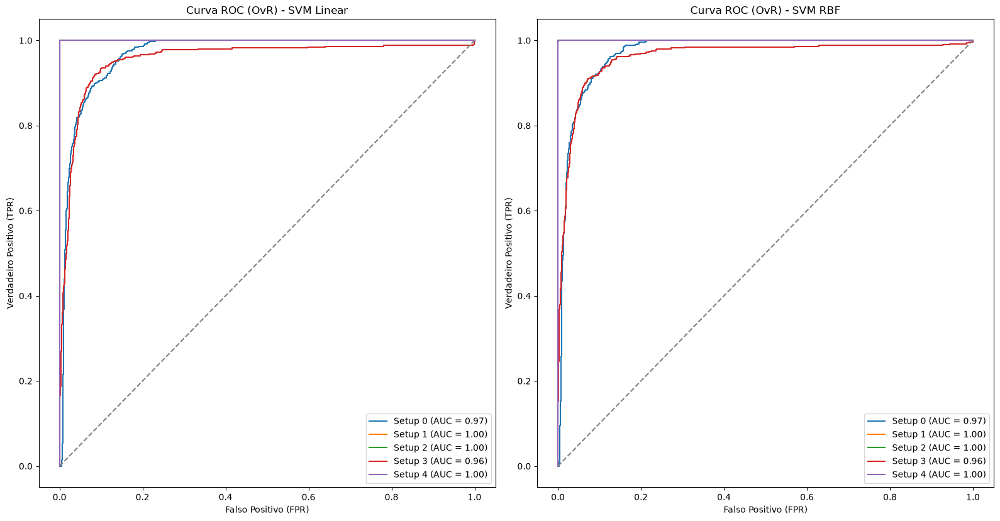

In [ ]:
# Lista das classes existentes

classes = [0.0, 1.0, 2.0, 3.0, 4.0]

# Binarização das classes
Y_bin = label_binarize(Y_df, classes=classes)

# Criação de figura
plt.figure(figsize=(16, 16))

# Loop que percorre todos os modelos do dicionário
for indice, (nome, modelo) in enumerate(modelos_svm.items()):

    # Criação de subplot
    plt.subplot(2, 2, indice + 1)

    modelo.fit(X_treino, y_treino)

    # Execução do cross validation
    predicted_proba = cross_val_predict(modelo, X_df, Y_df, cv=20, method="predict_proba")

    for i, classe in enumerate(classes):
        # Execução da função de curva ROC da classe atual
        fpr, tpr, _ = roc_curve(Y_bin[:, i], predicted_proba[:, i])
        roc_auc = auc(fpr, tpr)

        # Elaboração da curva ROC
        plt.plot(fpr, tpr, label=f"Setup {int(classe)} (AUC = {roc_auc:.2f})")

    # Elaboração da curva ROC (continuação)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Falso Positivo (FPR)")
    plt.ylabel("Verdadeiro Positivo (TPR)")
    plt.title(f"Curva ROC (OvR) - {nome}")
    plt.legend()

# Exibição dos gráficos
plt.tight_layout()
plt.show()

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


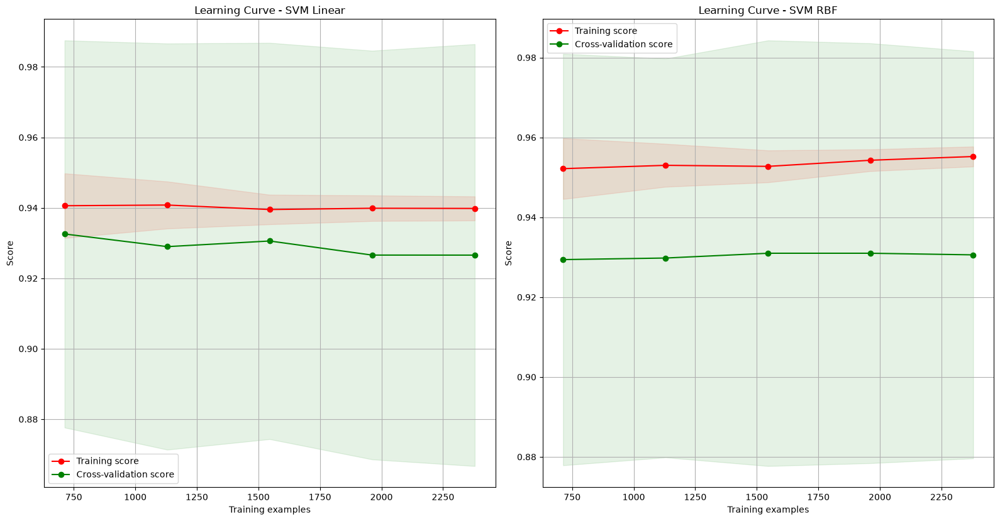

In [ ]:
# Curvas de aprendizado dos modelos SVM

plt.figure(figsize=(16, 16))

# Loop que percorre todos os modelos do dicionário
for indice, (nome, modelo) in enumerate(modelos_svm.items()):

    # Criação de subplot para alocação do gráfico da curva de crescimento dos modelos analizados
    plt.subplot(2, 2, indice + 1)

    modelo.fit(X_treino, y_treino)

    # Elaboração da curva de aprendizado 
    train_sizes, train_scores, test_scores = learning_curve(
        modelo,
        X_df,
        Y_df,
        cv=20,
        scoring='accuracy',
        n_jobs=-1,
        train_sizes=np.linspace(0.3, 1.0, 5),
        shuffle=True,
        random_state=42
    )

    # Média e desvio padrão do treino e teste
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)

    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Criação do gráfico da curva de aprendizado
    plt.title(f"Learning Curve - {nome}")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r"
    )

    plt.fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g"
    )

    plt.plot(
        train_sizes,
        train_scores_mean,
        'o-',
        color="r",
        label="Training score"
    )

    plt.plot(
        train_sizes,
        test_scores_mean,
        'o-',
        color="g",
        label="Cross-validation score"
    )

    plt.legend(loc="best")

# Exibição da imagem

plt.tight_layout()
plt.show()

Tendo os resultados de validação cruzada e os gráficos apresentados, podem-se realizar algumas conclusões:

**1.** Os dois modelos SVM apresentaram desempenho elevado e muito semelhante. O SVM Linear obteve acurácia e Média Macro F1 de aproximadamente 92,65%, enquanto o SVM com kernel RBF obteve aproximadamente 93,05% nas duas métricas. Assim, o kernel RBF apresentou uma melhora pequena na Média Macro F1.

**2.** Os Setups 1, 2 e 4 foram classificados com desempenho praticamente perfeito pelos dois modelos. Os menores F1-scores ocorreram nos Setups 0 e 3: aproximadamente 81% para o Setup 0 e 82% para o Setup 3. Portanto, a principal dificuldade dos modelos está em diferenciar a condição normal da condição de desbalanceamento.

**3.** As matrizes de confusão confirmam que os principais erros ocorrem entre Normal e Desbalanceado. No SVM Linear, 109 máquinas normais foram classificadas como desbalanceadas, enquanto 72 máquinas desbalanceadas foram classificadas como normais. No SVM RBF, esses valores foram 97 e 75, respectivamente.

**4.** As curvas ROC dos dois modelos apresentam comportamento praticamente idêntico. Os Setups 1, 2 e 4 obtiveram AUC igual a 1,00, indicando excelente separação dessas condições em relação às demais. O Setup 0 apresentou AUC de aproximadamente 0,97 e o Setup 3 apresentou AUC de aproximadamente 0,96. Embora esses valores também sejam excelentes, eles reforçam que Normal e Desbalanceado são as condições mais próximas entre si.

**5.** Nas curvas de aprendizado, os resultados de treino e de validação cruzada permanecem próximos e com valores altos. A diferença relativamente pequena entre as curvas de treino e validação indica que não há evidência forte de sobreajuste.

Com base nos resultados atuais, o SVM RBF pode ser considerado o melhor modelo preliminar, pois obteve a maior Média Macro F1 e a maior acurácia. Entretanto, a diferença para o SVM Linear é pequena.

#### **4. Aprimoramento dos modelos e seleção do melhor modelo**

#### **4.1 Nova Redução e PCA**

Os modelos elaboradas anteriormente foram construídos com base em uma redução prévia e explicada no final da sessão 2. Mesmo que tenhamos conseguido alguns resultados, ainda há espaço para reduções de dimensionalidade usando dos argumentos previamente utilizados na sessão 2. Por exemplo, considerando as conclusões que as informações provindas dos sensores de vibração possuem as melhores notas, porque não só considerá-los de forma a retirar a necessidade dos sensores de corrente e potência de entrada? Essa hipótese foi então aplicada em mais uma redução, como visto na célula a seguir:

In [ ]:
# Dataset Reduzido

X_df = df_param_norm.drop(columns=["DesvPad_I_entrada_A", 
                           "I_saida_A", 
                           "DesvPad _P_entrada_W", 
                           "Amp_I_saida_A", 
                           "DesvPad _I_saida_A", 
                           "Amp_P_entrada_W", 
                           "Kurtosis_I_entrada_A", 
                           "Amp_I_entrada_A", 
                           "Kurtosis_P_entrada_W",
                            "Kurtosis_I_saida_A",
                            "I_entrada_A",
                            "P_entrada_W",
                            ])

# Rótulos das entradas

Y_df = df_maquinas["tipo_setup"]

Além disso, é possível não só excluir parâmetros, mas também fundi-los se utilizando do PCA, o qual analiza a contribuição na taxa de variância de cada um dos parâmetros, tendo uns maiores contribuições de outros. Com essa lógica, é possível reduzir a quantidade de atributos utilizados para treinar os modelos sem perder a informação provinda dos sensores, por exemplo. Com esse novo dataset reduzido, podemos analisar a contribuição de variância de diferentes quantidade de componentes a partir do seguinte código:

Text(0.5, 1.0, 'n_components vs. Explained Variance Ratio')

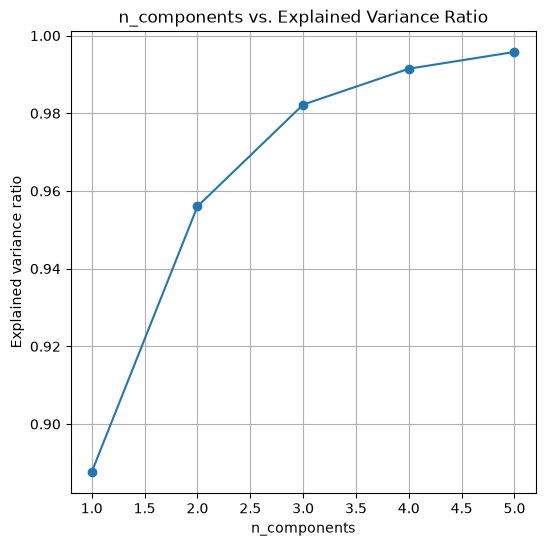

In [ ]:
# Lista com quantidade de componentes (o máximo de componentes deve ser menor que a quantidade de atributos total)

nums = np.arange(1, 6, 1)

# Lista de taxa de variância total

var_ratio = []

# Loop que percorre todos as quantidades de componente

for num in nums:

  # Criação do PCA 
  
  pca = PCA(n_components=num, random_state=42)

  # Aplicação do PCA no dataset

  pca.fit(X_df)

  # Soma das taxas de variância de todos os componentes gerados

  var_ratio.append(np.sum(pca.explained_variance_ratio_))

# Gráfico ilustrativo das diferentes taxas de variância variando com a quantidade de componentes gerados

plt.figure(figsize=(6,6),dpi=100)
plt.grid()
plt.plot(nums, var_ratio, marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance ratio')
plt.title('n_components vs. Explained Variance Ratio')


Nesse exemplo, fica evidente que, mesmo que com 6 componentes componham quase 100% da taxa de variância, o uso de 4 componentes também parece muito atraente pode ter uma taxa muito próxima de 100% também enquanto diminui a dimensionalidade do problema em 2. Dessa forma, pode-se utilizar do dataset reduzido junto com um PCA de 4 componentes para aplicar uma nova rodada de avaliações. As informações atualizadas podem ser vistas na célula a seguir:

In [ ]:
# Criação do PCA desejado

pca = PCA(n_components=4, random_state=42)

# Aplicação do PCA no dataset reduzido

X_pca = pca.fit_transform(X_df)

# Rótulos das entradas

Y_df = df_maquinas["tipo_setup"]

X_treino, X_teste, y_treino, y_teste = train_test_split(X_pca, Y_df, test_size = 0.3, random_state=1, shuffle=True)

A escolha de realizar a nova redução e o PCA podem trazer problemas aos desempenhos dos modelos, porém, caso a diferença não seja gritante, podemos conseguir resultados muito parecidos se utilizando de muito menos sensores, o que reflete em menores custos de implementação e manutenção no longo prazo sem prejudicar demais o desempenho.

#### **4.2 Teste com Modelos**

Definido essas reduções, basta testar os tipos de modelos preditivos utilizados previamente de forma a encontrar as melhores versões de cada um deles com base na média de F1 Score total. Tais versões foram delimitadas nas seguintes células:

#### **4.2.1 KNN Classifier**

#### **4.2.2 Decision Tree**

In [ ]:
# Criação de lista com diferentes tamanhos de árvore a serem testados

lista_tamanho_arvore = np.arange(1, 25, 1)

# Variáveis referentes ao melhor modelo encontrado

max_f1 = 0
componentes_max_f1 = 0
setup_0_max_f1 = 0
setup_1_max_f1 = 0
setup_2_max_f1 = 0
setup_3_max_f1 = 0
setup_4_max_f1 = 0
accuracy_max_f1 = 0
macro_avg_f1_max_f1 = 0
weighted_avg_max_f1 = 0
tamanho_max_f1 = 0
alpha_max_f1 = 0

# Loop que percorre todos os tamanhos de árvore disponíveis

for tamanho in lista_tamanho_arvore:

    # Criaçao do algoritmo DecisionTreeClassifier com o tamanho definido (random_state colocado para que a mesma resposta seja exibida em toda interação de código)

    decision_tree_origin = DecisionTreeClassifier(max_depth=tamanho, random_state=42)

    decision_tree_origin.fit(X_treino, y_treino)

    # Definição dos alphas do modelo com o tamanho atual

    path = decision_tree_origin.cost_complexity_pruning_path(X_pca, Y_df)
    ccp_alphas = path.ccp_alphas

    # Loop que percorre todos os alphas do tamanho de árvore atual

    for alpha in ccp_alphas:

        # Criação do modelo com tamanho e alpha variável

        decision_tree_alpha = DecisionTreeClassifier(max_depth=tamanho, ccp_alpha=alpha, random_state=42)

        decision_tree_alpha.fit(X_treino, y_treino)

        # Execução do cross validation com 20 folds

        predicted = cross_val_predict(decision_tree_alpha, X_pca, Y_df, cv = 20)

        # Criação do classification report em formato de dicionário para que seja possível extrair as informações de F1 Score mais facilmente

        dic_report = classification_report(Y_df, predicted, output_dict=True)

        # Coleta dos dados de interesse

        setup_0_f1 = dic_report["0.0"]["f1-score"] * 100
        setup_1_f1 = dic_report["1.0"]["f1-score"] * 100
        setup_2_f1 = dic_report["2.0"]["f1-score"] * 100
        setup_3_f1 = dic_report["3.0"]["f1-score"] * 100
        setup_4_f1 = dic_report["4.0"]["f1-score"] * 100
        accuracy = dic_report["accuracy"] * 100
        macro_avg_f1 = dic_report["macro avg"]["f1-score"] * 100
        weighted_avg_f1 = dic_report["weighted avg"]["f1-score"] * 100

        # Verificação se o modelo atual é o melhor modelo atual

        if macro_avg_f1 > max_f1:

            # Alocação das estatísticas do modelo nas suas respectivas variáveis

            max_f1 = macro_avg_f1
            tamanho_max_f1 = tamanho
            alpha_max_f1 = alpha
            setup_0_max_f1 = setup_0_f1
            setup_1_max_f1 = setup_1_f1
            setup_2_max_f1 = setup_2_f1
            setup_3_max_f1 = setup_3_f1
            setup_4_max_f1 = setup_4_f1
            accuracy_max_f1 = accuracy
            weighted_avg_max_f1 = weighted_avg_f1

# Criação de DataFrame para melhor visualização dos resultados entre diferentes tamanhos de árvore

print("Melhor Resultado Obtido - Decision Tree")
print(f"Tamanho Árvore: {tamanho_max_f1}")
print(f"Alpha: {alpha_max_f1}")
print(f"F1 Score Setup 0: {setup_0_max_f1}")
print(f"F1 Score Setup 1: {setup_1_max_f1}")
print(f"F1 Score Setup 2: {setup_2_max_f1}")
print(f"F1 Score Setup 3: {setup_3_max_f1}")
print(f"F1 Score Setup 4: {setup_4_max_f1}")
print(f"Acurácia: {accuracy_max_f1}")
print(f"Média Simples F1 Score {max_f1}")
print(f"Média Ponderada F1 Score: {weighted_avg_f1}")

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Melhor Resultado Obtido - Decision Tree
Tamanho Árvore: 10
Alpha: 0.0
F1 Score Setup 0: 66.60019940179461
F1 Score Setup 1: 99.60159362549801
F1 Score Setup 2: 98.41897233201581
F1 Score Setup 3: 66.60000000000001
F1 Score Setup 4: 98.48637739656913
Acurácia: 85.94810379241517
Média Simples F1 Score 85.94142855117552
Média Ponderada F1 Score: 23.66158550575323


#### **4.2.3 SVM**

In [ ]:
kernel = ["linear", "rbf"]
lista_c = [0.01, 0.1, 1, 10, 100]

# Variáveis referentes ao melhor modelo encontrado

max_f1 = 0
setup_0_max_f1 = 0
setup_1_max_f1 = 0
setup_2_max_f1 = 0
setup_3_max_f1 = 0
setup_4_max_f1 = 0
accuracy_max_f1 = 0
macro_avg_f1_max_f1 = 0
weighted_avg_max_f1 = 0
kernel_max_f1 = ""
c_max_f1 = 0

# Loop que percorre todos os modelos do dicionário

for kernel in lista_kernel:

    for valor_c in lista_c:

        # Modelo com kernel e valor de c atual

        modelo_svm = SVC(kernel = kernel, C = valor_c, probability=True, random_state = 42)

        modelo_svm.fit(X_treino, y_treino)

        # Execução do cross validation com 20 folds

        predicted = cross_val_predict(modelo_svm, X_pca, Y_df, cv=20)

        # Criação do classification report em formato de dicionário para que seja possível extrair as informações de F1 Score mais facilmente
        
        dic_report = classification_report(Y_df, predicted, output_dict=True)

        # Coleta dos dados de interesse
        
        setup_0_f1 = dic_report["0.0"]["f1-score"] * 100
        setup_1_f1 = dic_report["1.0"]["f1-score"] * 100
        setup_2_f1 = dic_report["2.0"]["f1-score"] * 100
        setup_3_f1 = dic_report["3.0"]["f1-score"] * 100
        setup_4_f1 = dic_report["4.0"]["f1-score"] * 100
        accuracy = dic_report["accuracy"] * 100
        macro_avg_f1 = dic_report["macro avg"]["f1-score"] * 100
        weighted_avg_f1 = dic_report["weighted avg"]["f1-score"] * 100

        # Verificação se o modelo atual é o melhor modelo atual

        if macro_avg_f1 > max_f1:

            # Alocação das estatísticas do modelo nas suas respectivas variáveis

            max_f1 = macro_avg_f1
            setup_0_max_f1 = setup_0_f1
            setup_1_max_f1 = setup_1_f1
            setup_2_max_f1 = setup_2_f1
            setup_3_max_f1 = setup_3_f1
            setup_4_max_f1 = setup_4_f1
            accuracy_max_f1 = accuracy
            weighted_avg_max_f1 = weighted_avg_f1
            kernel_max_f1 = kernel
            c_max_f1 = valor_c

# Criação de DataFrame para melhor visualização dos resultados entre diferentes tamanhos de árvore

print("Melhor Resultado Obtido - SVM")
print(f"Kernel: {kernel_max_f1}")
print(f"Valor C: {c_max_f1}")
print(f"F1 Score Setup 0: {setup_0_max_f1}")
print(f"F1 Score Setup 1: {setup_1_max_f1}")
print(f"F1 Score Setup 2: {setup_2_max_f1}")
print(f"F1 Score Setup 3: {setup_3_max_f1}")
print(f"F1 Score Setup 4: {setup_4_max_f1}")
print(f"Acurácia: {accuracy_max_f1}")
print(f"Média Simples F1 Score {max_f1}")
print(f"Média Ponderada F1 Score: {weighted_avg_f1}")

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\

Melhor Resultado Obtido - SVM
Kernel: rbf
Valor C: 1
F1 Score Setup 0: 74.14829659318637
F1 Score Setup 1: 100.0
F1 Score Setup 2: 99.8
F1 Score Setup 3: 74.60317460317461
F1 Score Setup 4: 100.0
Acurácia: 89.70059880239522
Média Simples F1 Score 89.7102942392722
Média Ponderada F1 Score: 89.30542705971277


c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


#### **4.3 Escolha do Melhor Modelo**

Como visto nas células anteriores, os melhores candidatos para o classificador de motores foram:

**1. KNN Classifier:**

**2. Decision Tree: Tamanho de Árvore 10 / Alpha 0 - 85.9%**

**3. SVM: Kernel RBF / C = 1 - 89.7%**

Percebe-se que, assim como previamente demonstrado, a diminuição de dimensão do problema por redução e agregação impactou os resultados dos modelos negativamente, mas esse impaacto não foi extremamente impactante (3%). Ainda sim, se obtêm ótimos F1 Scores em todos os modelos mas com metade dos sensores o que, como previamente mencionado, é benéfico no longo prazo.

De forma a decidir qual o melhor modelo a ser adotado, podemos construir a matriz de solução, curvas ROC e curva de aprendizado, antes vistos dentro de um próprio modelo, agora entre modelos. As informações citadas podem ser encontradas nas próximas células:

In [ ]:
# Melhores Modelos

# Modelo SVM 
svm_rbf_final = SVC(kernel='rbf', C = 1, probability=True, random_state=42)
svm_rbf_final.fit(X_treino, y_treino)

# Modelo Decision Tree
decision_tree_final = DecisionTreeClassifier(max_depth=10, ccp_alpha=0, random_state=42)
decision_tree_final.fit(X_treino, y_treino)

# Dicionário com os melhores modelos
modelos_motor = {
    "Decision Tree": decision_tree_final,
    "SVM RBF": svm_rbf_final
}

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



===== Decision Tree =====


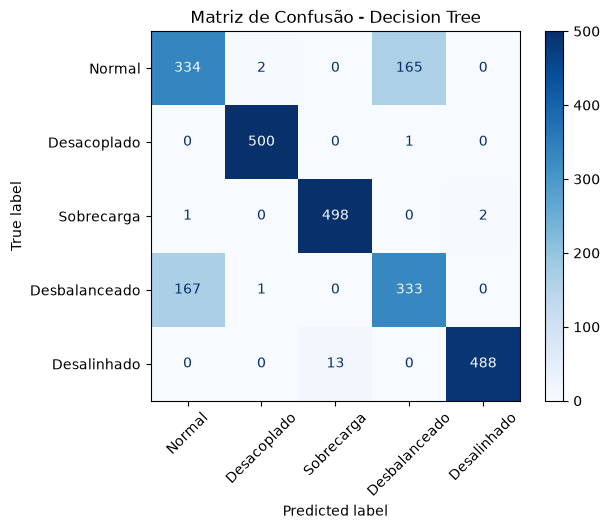

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\


===== SVM RBF =====


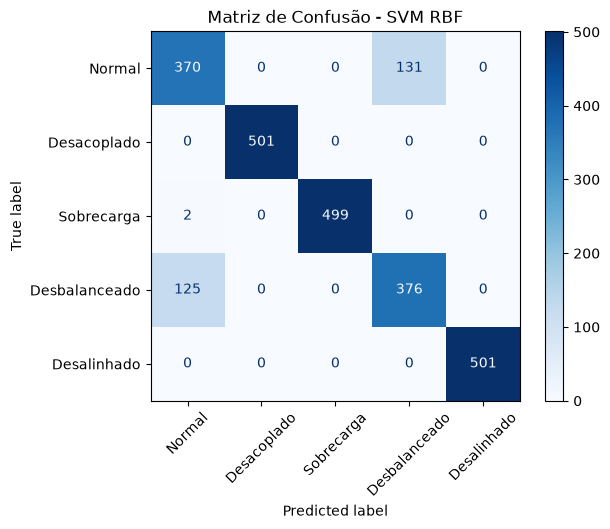

In [ ]:
# Classes do problema

classes_setup = [
    "Normal",
    "Desacoplado",
    "Sobrecarga",
    "Desbalanceado",
    "Desalinhado"
]

# Loop que percorre todos os modelos do dicionário

for nome, modelo in modelos_motor.items():

    # Execução do cross validation com 20 folds do modelo atual

    predicted = cross_val_predict(modelo, X_pca, Y_df, cv=20)

    # Exibição do nome do modelo ao qual o gráfico se refere

    print(f"\n===== {nome} =====")

    # Criação da matriz de confusão

    cm = confusion_matrix(Y_df, predicted)

    # Criação da imagem da matriz de confusão

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes_setup
    )

    # Exibição da matriz de confusão

    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xticks(rotation=45)
    plt.show()

c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\

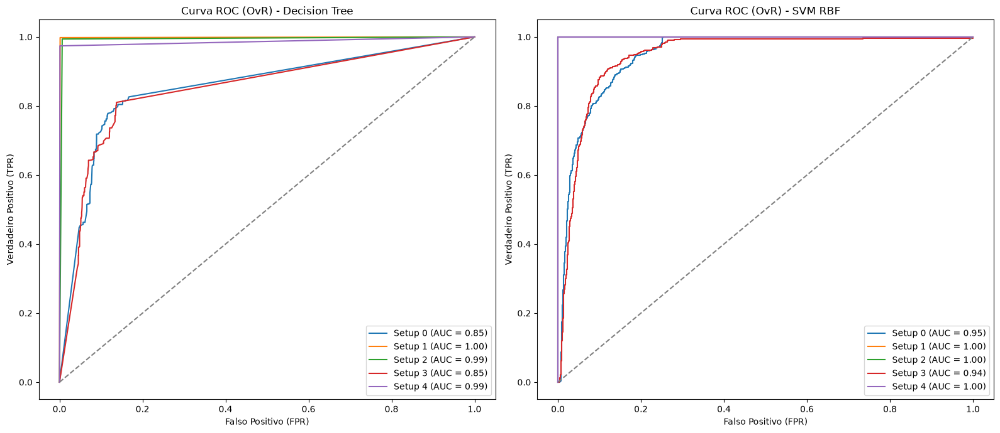

In [ ]:
# Lista das classes existentes

classes = [0.0, 1.0, 2.0, 3.0, 4.0]

# Binarização das classes uma vez que a curva ROC é feita apenas com modelos binários

Y_bin = label_binarize(Y_df, classes=classes)

# Criação de figura onde irão ser posicionados os gráficos de curvas ROC

plt.figure(figsize=(16, 7))

# Loop que percorre todos os modelos do dicionário

for indice, (nome, modelo) in enumerate(modelos_motor.items()):

    # Criação de subplot para alocação do gráfico da curva ROC do tipo de modelo analisado

    plt.subplot(1, 2, indice + 1)

    # Execução do cross validation com 20 folds com probabilidades o qual é importante para elaboração da curva ROC

    predicted_proba = cross_val_predict(modelo, X_pca, Y_df, cv=20, method="predict_proba")

    # Loop que passa por cada classe para elaborar sua curva ROC

    for i, classe in enumerate(classes):

        # Execução da função de curva ROC da classe atual

        fpr, tpr, _ = roc_curve(Y_bin[:, i], predicted_proba[:, i])
        roc_auc = auc(fpr, tpr)

        # Elaboração da curva ROC

        plt.plot(fpr, tpr, label=f"Setup {int(classe)} (AUC = {roc_auc:.2f})")

    # Elaboração da curva ROC (continuação)

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Falso Positivo (FPR)")
    plt.ylabel("Verdadeiro Positivo (TPR)")
    plt.title(f"Curva ROC (OvR) - {nome}")
    plt.legend()

# Exibição dos gráficos

plt.tight_layout()
plt.show()

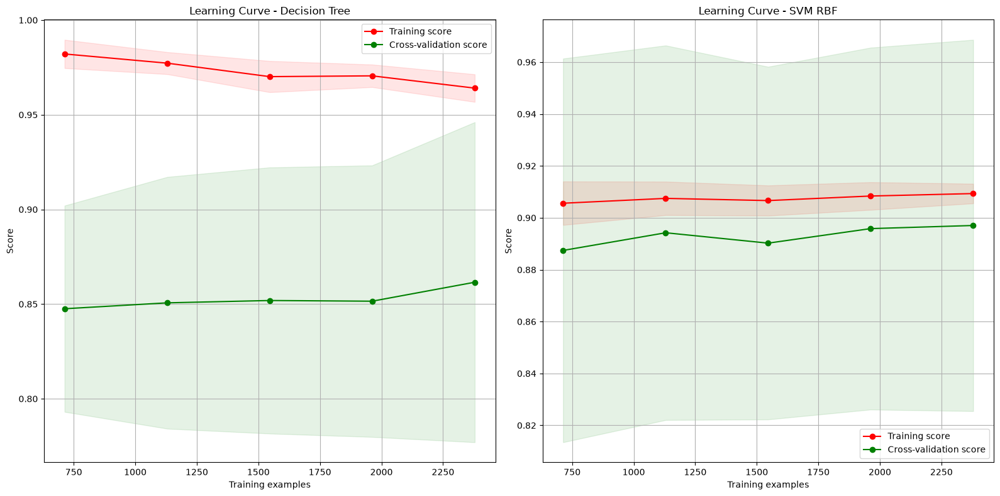

In [ ]:
# Curvas de aprendizado dos modelos

plt.figure(figsize=(16, 8))

# Loop que percorre todos os modelos do dicionário

for indice, (nome, modelo) in enumerate(modelos_motor.items()):

    # Criação de subplot para alocação do gráfico da curva de aprendizado dos modelos analizados

    plt.subplot(1, 2, indice + 1)

    # Elaboração da curva de aprendizado 
    
    train_sizes, train_scores, test_scores = learning_curve(
        modelo,
        X_pca,
        Y_df,
        cv=20,
        scoring='accuracy',
        n_jobs=-1,
        train_sizes=np.linspace(0.3, 1.0, 5),
        shuffle=True,
        random_state=42
    )

    # Média e desvio padrão do treino e teste# Média e desvio padrão do treino e teste  

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)

    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Criação do gráfico da curva de aprendizado

    plt.title(f"Learning Curve - {nome}")
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()

    plt.fill_between(
        train_sizes,
        train_scores_mean - train_scores_std,
        train_scores_mean + train_scores_std,
        alpha=0.1,
        color="r"
    )

    plt.fill_between(
        train_sizes,
        test_scores_mean - test_scores_std,
        test_scores_mean + test_scores_std,
        alpha=0.1,
        color="g"
    )

    plt.plot(
        train_sizes,
        train_scores_mean,
        'o-',
        color="r",
        label="Training score"
    )

    plt.plot(
        train_sizes,
        test_scores_mean,
        'o-',
        color="g",
        label="Cross-validation score"
    )

    plt.legend(loc="best")

# Exibição da imagem

plt.tight_layout()
plt.show()

Com esses gráficos, é possível realizar as seguintes considerações entre os modelos:

**1.** Pelo classification_report, fica evidente que o SVM RBF possui melhores resultados: mesmo que ambos tenham capacidade de classificar as classes 1, 2 e 4 de forma quase perfeita, é evidente a dificuldade de separar as classes 0 e 3 devido às suas semelhanças referentes aos parâmetros utilizados. Porém, o SVM consegue realizar essa separação consideravelmente melhor em comparação com o Decision Tree;

**2.** Na Matriz de confusão, esse diferencial fica ainda mais evidente pela diminuição dos casos de classificação equivocadas das classes 0 e 3. Como mencionado em seções anteriores, sendo difícil a separação das classes mencionadas, o melhor é se ter um caso onde a quantidade de ocorrências de falsos negativos de motores desbalanceados é a menor possível visto que significa que uma quantidade menor de motores estarão sobre risco de quebra ou defeito visto a falta de aviso prévio e capacidade preditiva;

**3.** A Curva ROC também mostra um comportamento melhor do SVM em comparação ao Decision Tree, uma vez que se consegue uma maior taxa de verdadeiros positivos (VP) com uma menor ocorrência de falsos positivos (FP);

**4.** Por fim, na curva de aprendizado, por mais que a curva de treinamento da Decision Tree seja superior, a curva de validação ainda possui um rendimento abaixo comparado à curva de SVM. Se houvesse um incremento da quantidade de dados, é possível que essa curva pudesse ser melhorada, mas, como não se é possível realizar a extração de mais dados, fica evidente que, nesse caso, o SVM continua superior;

#### **5. Função de classificação**

Escolhido o modelo **(SVM RBF)**, pode-se criar uma função a qual recebe os inputs dos sensores de vibração do motor de forma a realizar sua classificação. Essa função pode ser vista a seguir:

In [ ]:
# Função que recebe o dataset original e as informações dos sensores de vibração

def motor_svm_rbf (S1_f1_dBrms, S1_f2_dBrms, S1_f3_dBrms, S2_f1_dBrms, S2_f2_dBrms, S2_f3_dBrms):

    X_df = df_maquinas.iloc[:, 2:]

    # Dicionário de correspondências das classes com seus números

    dicionario_classes = {0.0: "Normal",
                          1.0: "Desacoplado",
                          2.0: "Sobrecarga",
                          3.0: "Desbalanceado",
                          4.0: "Desalinhado"}

    # Alocação das informações dos sensores em variáveis locais

    s1_f1 = S1_f1_dBrms
    s1_f2 = S1_f2_dBrms
    s1_f3 = S1_f3_dBrms
    s2_f1 = S2_f1_dBrms
    s2_f2 = S2_f2_dBrms
    s2_f3 = S2_f3_dBrms

    # Lista dos dados dos sensores em ordem

    lista_sensores = [s1_f1, s1_f2, s1_f3, s2_f1, s2_f2, s2_f3]

    # Redução do dataset original

    X_df_reduzido = X_df.drop(columns=["DesvPad_I_entrada_A", 
                           "I_saida_A", 
                           "DesvPad _P_entrada_W", 
                           "Amp_I_saida_A", 
                           "DesvPad _I_saida_A", 
                           "Amp_P_entrada_W", 
                           "Kurtosis_I_entrada_A", 
                           "Amp_I_entrada_A", 
                           "Kurtosis_P_entrada_W",
                            "Kurtosis_I_saida_A",
                            "I_entrada_A",
                            "P_entrada_W",
                            ])

    # Aplicação da normalização do dataset

    scaler = StandardScaler()
    scaler.set_output(transform="pandas")
    X_df_norm = scaler.fit_transform(X_df_reduzido)

    # Transformação dos dados dos sensores usando da normalização feita com o dataset

    lista_sensores_norm = scaler.transform(np.array(lista_sensores).reshape(1, -1))

    # Criação e aplicação do PCA

    pca = PCA(n_components=4, random_state=422)
    pca.fit(X_df_norm)

    # Transformação dos dados dos sensores usando do PCA feita com o dataset

    lista_sensores_pca = pca.transform(lista_sensores_norm)

    # Predição do Modelo usando os dados dos sensores transformados

    predict = svm_rbf_final.predict(lista_sensores_pca)[0]

    # Retorna o texto que indica qual a classificação do motor entre as classes previstas

    return (f"O motor analizado está {dicionario_classes[predict]}")

In [ ]:
# Teste do modelo

print(motor_svm_rbf(-50, -63, -47, -59, -73, -49))

O motor analizado está Normal


c:\Users\lucas\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
